# PCLab#4 - Group 4 - Claas Boumans Giuliano Ciaramella Theodor Nissen-Meyer

**20598 – Finance with Big Data · PC Lab #4: Predicting Stock Returns with ML**

*Time required: approximately 12 hours. Difficulty: 7 out of 10. (excl. optional tasks)*

## 0. Setup
Libraries and the chart theme of the previous labs. Constants and helpers are defined where they are first needed. With the forecasts cached in 3.2 and 3.5 the notebook runs in about a minute, without them in about 23.

In [197]:
import os
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, PercentFormatter
import statsmodels.api as sm
from scipy.stats import norm
from sklearn.base import clone
from sklearn.linear_model import BayesianRidge, ElasticNet, LinearRegression, Ridge
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
try:                                                                # only needed to retrain the models of Task #3:
    import lightgbm as lgb                                          # their cached forecasts load without them (3.2)
    import torch
    from torch import nn
except ImportError:
    lgb = torch = nn = None

pd.set_option("display.float_format", "{:,.4f}".format)
warnings.filterwarnings("ignore", category=FutureWarning)           # pandas' notice on its new stack() implementation

In [198]:
# Chart theme inspired by The Economist: white background, horizontal gridlines,
# bold left-aligned titles, red rule on top, the magazine's blue/teal palette.
ECONOMIST_RED = "#E3120B"
ECONOMIST_COLORS = ["#006BA2", "#3EBCD2", "#379A8B", "#EBB434", "#B4BA39",
                    "#9A607F", "#D1B07C", "#758D99", "#DB444B"]
ECONOMIST_BLUES = LinearSegmentedColormap.from_list("economist_blues", ["#C5E4F0", "#3EBCD2", "#006BA2", "#0C2A4A"])
DARK, GREY, LIGHT_GREY = "#333333", "#758D99", "#C9D3D9"      # text and reference lines; benchmarks
GRID = "#D0D0D0"

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.prop_cycle": plt.cycler(color=ECONOMIST_COLORS),
    "axes.grid": True,
    "axes.grid.axis": "y",              # horizontal gridlines only
    "grid.color": GRID,
    "axes.axisbelow": True,             # gridlines behind the data
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.titlelocation": "left",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": DARK,
    "xtick.color": DARK,
    "ytick.color": DARK,
    "ytick.left": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "legend.frameon": False,
    "lines.linewidth": 1.6,
})

In [199]:
# Chart helpers, shared by every figure of the notebook
WHITE_BOX = {"facecolor": "white", "edgecolor": "none", "pad": 0.5}    # behind a label that crosses a line, improve readability


def show(title=None):
    '''Add the headline, the red rule and the tag on top of the current figure, then display it.'''
    fig = plt.gcf()
    if title:
        fig.suptitle(title, x=0.01, ha="left", fontsize=15, fontweight="bold")
    fig.tight_layout()
    fig.add_artist(plt.Line2D([0, 1], [1.02, 1.02], transform=fig.transFigure, color=ECONOMIST_RED, lw=1.5))
    fig.add_artist(plt.Rectangle((0, 1.02), 0.035, 0.015, transform=fig.transFigure, color=ECONOMIST_RED,
                                 clip_on=False))
    plt.show()


def vertical_grid(ax):
    '''Vertical gridlines only, for charts read along the x-axis.'''
    ax.grid(False, axis="y")
    ax.grid(True, axis="x", color=GRID)


def annotate(ax, text, xy, offset=(9, 0), **kwargs):
    '''
    Produce a text next to the point x|y, shifted by `offset` (in points): to its right for a positive horizontal shift,
    to its left for a negative one, centred on it for none. Other arguments go to ax.annotate.
    '''
    dx = offset[0]
    style = {"ha": "left" if dx > 0 else "right" if dx < 0 else "center", "va": "center", "fontsize": 9.5,
             "color": DARK}
    ax.annotate(text, xy, xytext=offset, textcoords="offset points", **{**style, **kwargs})

## Task #1 – Basic manipulation and descriptive statistics
Task #1 uses only the lab files: daily closing prices and volumes (in shares) of eight stocks and the S&P 500, January 2012 to August 2020.

In [200]:
LAB_PRICES, LAB_VOLUMES = "Data_PCLab4_Stock_Price.csv", "Data_PCLab4_Stock_Volume.csv"


def load_lab(path):
    '''One lab file: a column per security, indexed by date.'''
    return pd.read_csv(path, parse_dates=["Date"]).sort_values("Date").set_index("Date")


prices, volumes = load_lab(LAB_PRICES), load_lab(LAB_VOLUMES)
stocks = list(prices.columns.drop("sp500"))

same_layout = prices.index.equals(volumes.index) and prices.columns.equals(volumes.columns)
missing = int(prices.isna().sum().sum() + volumes.isna().sum().sum())
print(f"Sample: {prices.index[0].date()} to {prices.index[-1].date()} ({len(prices):,} trading days), "
      f"securities: {list(prices.columns)}")
print("Same days and columns in both files:", same_layout, "| missing values:", missing,
      "| days with zero volume:", int((volumes == 0).sum().sum()))

Sample: 2012-01-12 to 2020-08-11 (2,159 trading days), securities: ['AAPL', 'BA', 'T', 'MGM', 'AMZN', 'IBM', 'TSLA', 'GOOG', 'sp500']
Same days and columns in both files: True | missing values: 0 | days with zero volume: 0


### Optional description of the sample

In [201]:
def trading_activity(prices, volumes):
    '''Average daily trading of every stock, in shares and in dollars (closing price x shares), descending.'''
    shares = volumes[stocks].mean()
    dollars = (prices[stocks] * volumes[stocks]).mean()
    return pd.DataFrame({"shares per day": shares, "dollars per day": dollars}).sort_values("dollars per day", ascending=False)

activity = trading_activity(prices, volumes)
index_volume = volumes["sp500"]
print(f"Apple, average day: {(volumes['AAPL'].mean() / 1e6):.1f}m shares")
print(f"S&P 500, busiest day: {(index_volume.max() / 1e9):.2f}bn shares on {index_volume.idxmax():%d %b %Y}")
print(f"Most traded: {activity['shares per day'].idxmax()} in shares, {activity['dollars per day'].idxmax()} in dollars")

Apple, average day: 58.2m shares
S&P 500, busiest day: 9.04bn shares on 20 Mar 2020
Most traded: AAPL in shares, AAPL in dollars


### 1.1 Volumes over time, raw and normalised
Daily volumes are noisy and hard to visualize, so we plot 20-day averages: in shares on a log scale (raw) and relative to each security's average day (normalised, 1 = an average days volume). The dashed line marks the start of the COVID-19 pandemic.

In [202]:
PANDEMIC = pd.Timestamp("2020-03-11")                                   # the WHO declares COVID-19 a pandemic


def millions(value, _):
    '''Axis label in millions or billions of shares.'''
    return f"{value / 1e9:g}bn" if value >= 1e9 else f"{value / 1e6:g}m"


def plot_volumes(volumes):
    '''20-day average volume of every security, in shares (log scale) and relative to its own average day.'''
    smooth = volumes.rolling(20).mean().dropna()
    normalised = smooth / volumes.mean()
    fig, (raw, relative) = plt.subplots(1, 2, figsize=(17, 6))

    for color, column in zip(ECONOMIST_COLORS, smooth.columns):
        style = {"color": DARK, "lw": 2.4} if column == "sp500" else {"color": color, "lw": 1.5}
        raw.plot(smooth.index, smooth[column], label=column, **style)
        relative.plot(normalised.index, normalised[column], **style)

    raw.set_yscale("log")
    raw.yaxis.set_major_formatter(FuncFormatter(millions))
    raw.set_ylim(top=smooth.values.max() * 4)                                     # room for the legend
    raw.set_title("Raw (log scale): levels not comparable across stocks")
    raw.legend(loc="upper left", ncol=5, fontsize=10)

    boeing = normalised["BA"]
    relative.axhline(1, color=DARK, lw=0.8)
    relative.set_title("Normalised (1 = average day): March 2020 lifts every security")
    annotate(relative, f"Boeing: {boeing.max():.0f} times\nits average day", (boeing.idxmax(), boeing.max()),
             offset=(-28, 0), va="top", fontsize=10.5)
    annotate(relative, "COVID-19 declared\na pandemic, 11 Mar 2020", (PANDEMIC, 0.72),
             xycoords=("data", "axes fraction"), offset=(-6, 0), va="top", fontsize=10.5)
    for ax in (raw, relative):
        ax.axvline(PANDEMIC, color=DARK, lw=1, ls="--")
        ax.grid(False, axis="x")
    show("Trading volume of the lab sample, 20-day averages, 2012-2020")

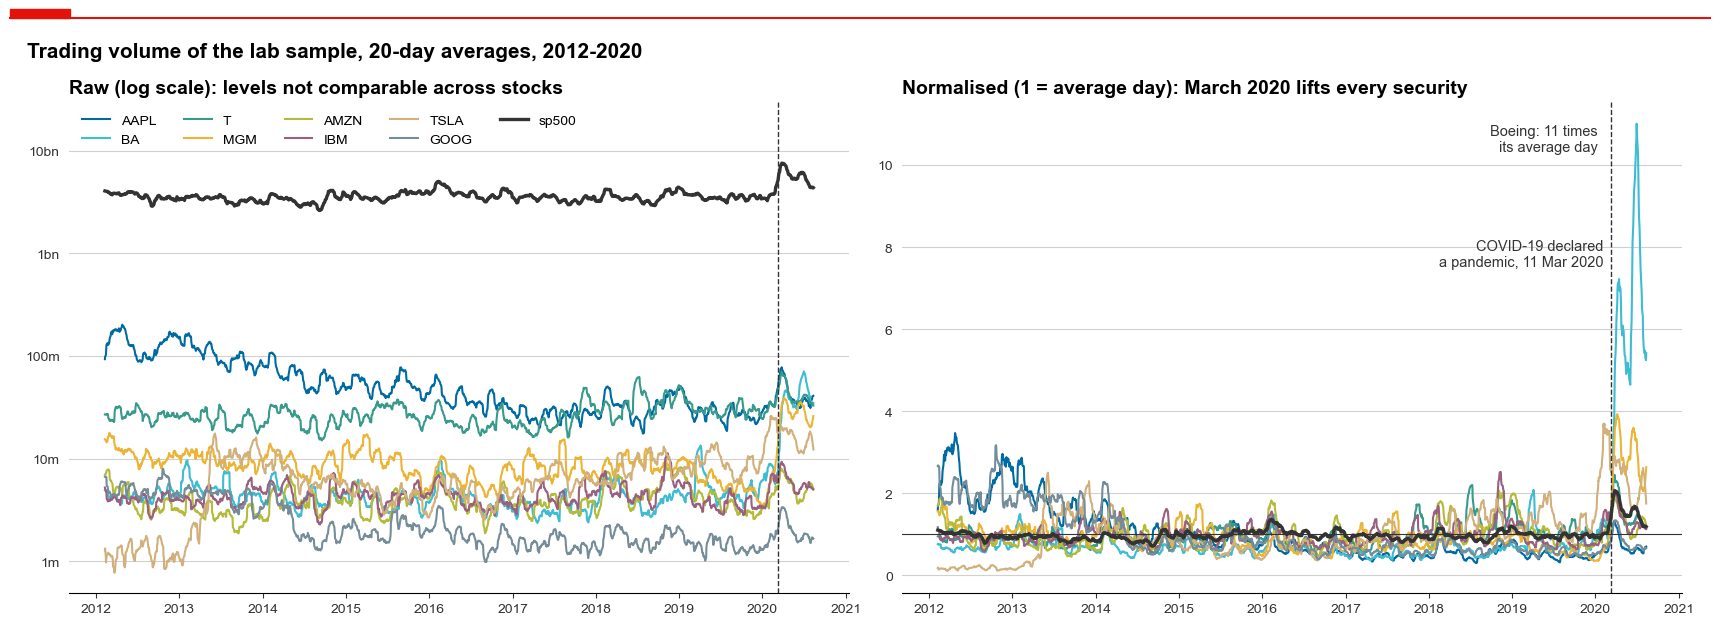

March 2020, times the average day: BA 5.3, MGM 3.5, TSLA 2.7, T 2.3, sp500 2.0, IBM 1.9, AMZN 1.8, GOOG 1.3, AAPL 1.2


In [203]:
plot_volumes(volumes)
march = (volumes.loc["2020-03"].mean() / volumes.mean()).sort_values(ascending=False)
print("March 2020, times the average day:", ", ".join(f"{name} {value:.1f}" for name, value in march.items()))

**Comments – 1.1**

- **Raw volumes are not comparable** (left): share volumes differ by more than a factor of 10 across the stocks and drift with the share price. Apple's and Alphabet's fall as their prices rise, partly because the same amount of money buys fewer shares, and perhaps because higher prices make the stocks less accessible to some investors.
- **March 2020 lifts every security** (right, dashed line): all trade above their average day, the S&P 500 at 2.0 times, the stocks at 1.2 (Apple) to 5.3 times (Boeing). Stock-specific news drives the extremes, such as Boeing at 11 times its average day in June 2020, after the 737 MAX groundings and the collapse of air travel.
- **Hence the volume signals of Task #2 compare a stock's recent volume with its own past year.**

### 1.2 Do returns and volumes move together?
We correlate the daily change in log volume $\Delta \ln V_t$ with the daily return $r_t$ (does volume rise when prices rise?), the absolute return (when prices move?) and the next day's return (does volume predict?). The point clouds pool the eight stocks, one point per stock-day (days beyond the axes are left out). The line averages the points in each bin with at least 100 stock-days.

In [204]:
returns = prices.pct_change().dropna()
volume_change = np.log(volumes).diff().dropna()                     # daily change in log volume

correlations = pd.DataFrame({
    "return": returns.corrwith(volume_change),
    "absolute return": returns.abs().corrwith(volume_change),
    "next day's return": volume_change.corrwith(returns.shift(-1)),
})

# the eight stocks pooled, one row per stock-day
pooled = pd.DataFrame({"return": returns[stocks].stack(), "volume change": volume_change[stocks].stack(),
                       "next day's return": returns[stocks].shift(-1).stack()}).dropna()

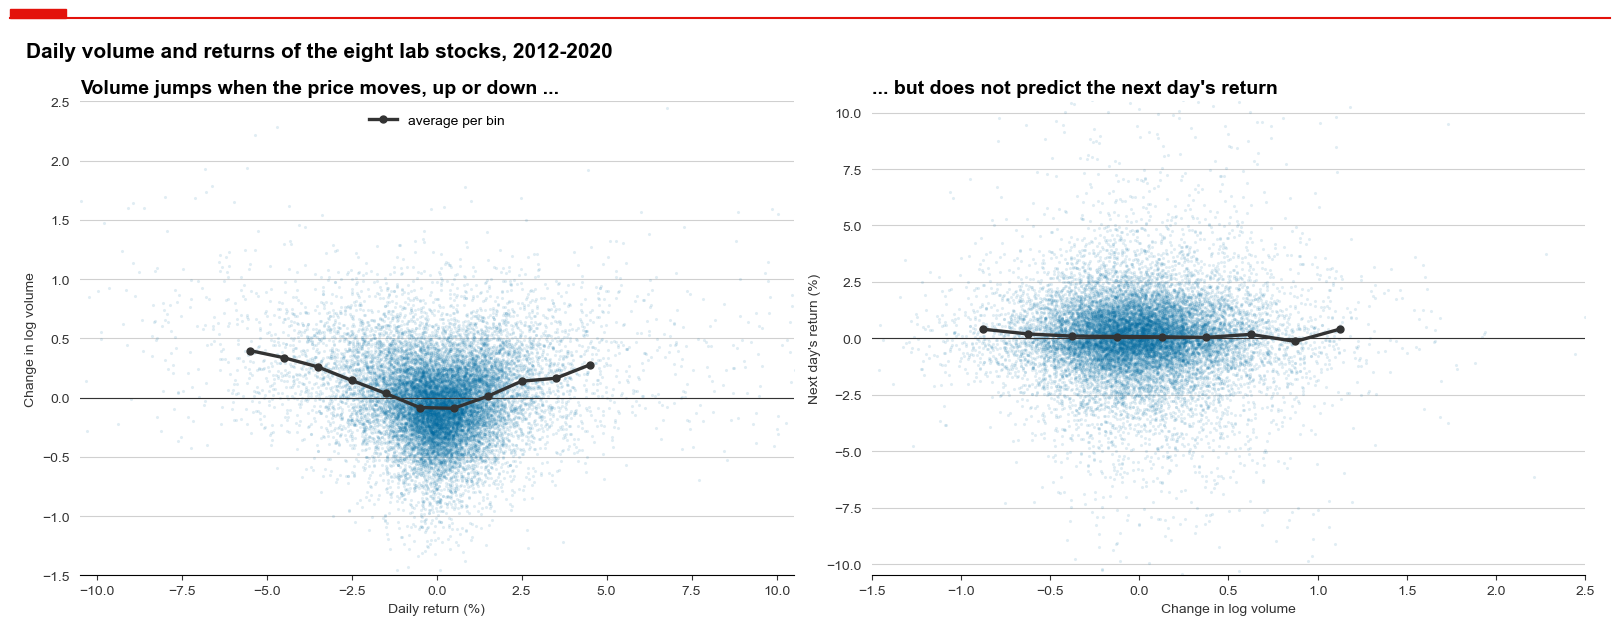

In [205]:
RETURN_RANGE, VOLUME_RANGE = (-10.5, 10.5), (-1.5, 2.5)             # axis limits: returns in %, changes in log volume


def binned_scatter(ax, x, y, bins, x_scale=1, y_scale=1):
    '''
    Point cloud of two columns of `pooled`, y against x, with the average of y in every bin of x
    that holds at least 100 stock-days. The scales turn returns into percent.
    '''
    ax.scatter(pooled[x] * x_scale, pooled[y] * y_scale, s=5, alpha=0.12, color=ECONOMIST_COLORS[0], lw=0,
               rasterized=True)
    grouped = pooled.groupby(pd.cut(pooled[x], bins), observed=True)[y]
    means = grouped.mean()[grouped.size() >= 100]
    ax.plot([interval.mid * x_scale for interval in means.index], means * y_scale, color=DARK, lw=2.4, marker="o",
            ms=5, label="average per bin")
    ax.axhline(0, color=DARK, lw=0.8)
    ax.grid(False, axis="x")


fig, (same_day, next_day) = plt.subplots(1, 2, figsize=(16, 6))

binned_scatter(same_day, "return", "volume change", bins=np.arange(-0.10, 0.1001, 0.01), x_scale=100)
same_day.set(xlim=RETURN_RANGE, ylim=VOLUME_RANGE, xlabel="Daily return (%)", ylabel="Change in log volume",
             title="Volume jumps when the price moves, up or down ...")
same_day.legend(loc="upper center")

binned_scatter(next_day, "volume change", "next day's return", bins=np.arange(-1.5, 2.51, 0.25), y_scale=100)
next_day.set(xlim=VOLUME_RANGE, ylim=RETURN_RANGE, xlabel="Change in log volume", ylabel="Next day's return (%)",
             title="... but does not predict the next day's return")

show("Daily volume and returns of the eight lab stocks, 2012-2020")

In [206]:
size = pd.cut(pooled["return"].abs(), [0, 0.01, 0.03, 0.05, np.inf], include_lowest=True,
              labels=["below 1%", "1% to 3%", "3% to 5%", "above 5%"])
by_size = pooled.groupby(size, observed=True)["volume change"].mean()
print("Average change in log volume by the size of the day's return:", by_size.round(2).to_dict())
print("Correlation with the change in log volume:")
for measure in correlations:
    of_stocks = correlations.loc[stocks, measure]
    print(f"  {measure:<18} the eight stocks {of_stocks.min():+.2f} to {of_stocks.max():+.2f}, "
          f"the S&P 500 {correlations.loc['sp500', measure]:+.2f}")

Average change in log volume by the size of the day's return: {'below 1%': -0.09, '1% to 3%': 0.05, '3% to 5%': 0.24, 'above 5%': 0.45}
Correlation with the change in log volume:
  return             the eight stocks -0.12 to +0.05, the S&P 500 -0.09
  absolute return    the eight stocks +0.27 to +0.47, the S&P 500 +0.13
  next day's return  the eight stocks -0.05 to +0.03, the S&P 500 -0.02


**Comments – 1.2**

- **Volume follows the size of the return, not its sign** (left): on days when a stock moves by more than 5%, its log volume rises by 0.45 on average, about 57% more shares. On days below 1% it falls by 0.09. The correlation with the absolute return lies between 0.27 and 0.47 for the stocks, with the return itself between −0.12 and +0.05: news brings in traders, good or bad.
- **Volume does not predict the next day's return** (right): the correlations lie between −0.05 and +0.03.

## Task #2 – Train and test samples, OLS and Ridge regression
### 2.1 Data, signals and targets
**Data.** Eight stocks are too few for machine learning and long-short portfolios (*Gu et al., 2020* use nearly 30,000). We download daily prices and volumes, adjusted for splits and dividends, for the 503 tickers of PC Lab #2 and the index, from January 2011 so that the one-year signals have a history on the first day of the lab sample.

In [207]:
SP500_LIST = "sp500_tickers_pclab2.csv"                              # the S&P 500 list scraped in PC Lab #2
QUOTES_FILE = "sp500_ohlcv_2011-01-01_to_2020-08-11.csv.gz"          # Yahoo Finance download, cached on disk
DOWNLOAD_START = "2011-01-01"                                        # one year of history for the one-year signals
SAMPLE_START, SAMPLE_END = "2012-01-12", "2020-08-11"                # the window of the lab files
MARKET = "^GSPC"                                                     # Yahoo's ticker of the S&P 500 index


def load_quotes(cache=QUOTES_FILE):
    '''
    Daily open, high, low, close and volume of the PC Lab #2 S&P 500 list and of the index (Yahoo Finance),
    adjusted for splits and dividends. Cached on disk: the download takes about 20 seconds.
    '''
    if not os.path.exists(cache):
        import yfinance as yf                                            # only needed for the download
        tickers = pd.read_csv(SP500_LIST)["ticker"].tolist()
        end = pd.Timestamp(SAMPLE_END) + pd.Timedelta(days=1)            # yfinance treats the end date as exclusive
        quotes = yf.download(tickers + [MARKET], start=DOWNLOAD_START, end=end, auto_adjust=True, progress=False)
        quotes.dropna(axis=1, how="all").round(4).to_csv(cache)
    return pd.read_csv(cache, header=[0, 1], index_col=0, parse_dates=True)

In [208]:
quotes = load_quotes()
market_close = quotes[("Close", MARKET)]
quotes = quotes.drop(columns=MARKET, level=1)
close, volume = quotes["Close"], quotes["Volume"].where(quotes["Volume"] > 0)      # a zero volume is a missing record

traded = close.loc[SAMPLE_START:].notna()
print(f"Stocks with Yahoo data: {close.shape[1]} of the {len(pd.read_csv(SP500_LIST))} tickers, "
      f"{close.index[0]:%Y-%m-%d} to {close.index[-1]:%Y-%m-%d}")
print(f"Traded on the first day of the lab sample: {traded.iloc[0].sum()} | on the last day: {traded.iloc[-1].sum()} "
      f"| on every day: {traded.all().sum()}")

# Yahoo against the lab file: the eight lab stocks and the index
yahoo_returns = close[stocks].assign(sp500=market_close).pct_change(fill_method=None)
agreement = yahoo_returns.loc[returns.index].corrwith(returns)
print(f"Correlation of daily returns with the lab file: {agreement.min():.3f} to {agreement.max():.3f}, "
      f"{(agreement.round(3) == 1).sum()} of the {len(agreement)} series at 1.000")

Stocks with Yahoo data: 485 of the 503 tickers, 2011-01-03 to 2020-08-11
Traded on the first day of the lab sample: 436 | on the last day: 485 | on every day: 436
Correlation of daily returns with the lab file: 0.984 to 1.000, 6 of the 9 series at 1.000


**Comments – 2.1, the data**

- **485 of the 503 tickers have data.** The other 18 were listed after August 2020. 436 stocks trade on every day of the lab window and 49 were listed during it, so each day uses the stocks with the history a signal needs.
- **Returns agree with the lab file** (correlations of 0.984 to 1.000). The gaps for AT&T and IBM come from dividend and spin-off adjustments the lab file lacks.
- **Survivorship bias:** these are today's members, so companies that left the index since 2012 are missing and companies that grew into it are present, which raises average returns (PC Lab #2). A full correction would need the historical index members. 4.1 checks in part whether the bias drives the portfolio results.

**Signals and targets.** We predict the return of stock $i$ from the close of day $t$ to that of day $t+h$, $r_{i,t \to t+h} = P_{i,t+h}/P_{i,t} - 1$, for $h$ = 5 and 20 trading days. The slides' 60 days would leave the 2.2-year test period with fewer than nine non-overlapping quarters. Therefore we decided to exclude this time window. The **four base signals** are the slides' information set over the past $w$ = 5 and 20 days:
- **Returns** (*return 5d*, *return 20d*): $P_{i,t}/P_{i,t-w} - 1$, for short-term reversal and momentum (Jegadeesh, 1990);
- **Volumes** (*volume 5d*, *volume 20d*): $\ln$(average volume of the past $w$ days / average volume of the past year), abnormal volume as a sign of news, measured against the stock's own past year (1.1).

The same function defines the eight signals of Task #2 bis.

**Scaling.** Each day every stock signal is ranked across stocks and mapped into $[-1, 1]$ (Gu et al., 2020), so outliers lose their weight and the scale does not drift between calm years and the crash. The market's returns, the same for all stocks on a day, get the slides' `MinMaxScaler`, fitted on the estimation days only.

In [209]:
HORIZONS = [5, 20]      # forecast horizons in trading days: a week and a month
WINDOWS = [5, 20]       # look-back windows of the price and volume signals
DAYS = 252              # trading days per year: the one-year signals here, annualising in Task #4

BASE = [f"return {w}d" for w in WINDOWS] + [f"volume {w}d" for w in WINDOWS]
EXTRA = ["beta", "volatility 20d", "max return 20d", "52-week high", "range position 20d", "dollar volume 20d"]
MARKET_SIGNALS = [f"market {w}d" for w in WINDOWS]
STOCK_SIGNALS = BASE + EXTRA
ALL_SIGNALS = STOCK_SIGNALS + MARKET_SIGNALS


def stock_signals(close, volume, high, low, market_close):
    '''Every signal of stock i known at the close of day t, one frame (days x stocks) per signal.'''
    returns, market_returns = close.pct_change(fill_method=None), market_close.pct_change()
    one_year = {"window": DAYS, "min_periods": 200}
    normal_volume = volume.rolling(**one_year).mean()                   # the stock's average day over the past year
    market_variance = market_returns.rolling(**one_year).var()
    lowest, highest = low.rolling(20).min(), high.rolling(20).max()     # the range of the past 20 days
    signals = {}
    for w in WINDOWS:
        signals[f"return {w}d"] = close / close.shift(w) - 1
        signals[f"volume {w}d"] = np.log(volume.rolling(w).mean() / normal_volume)
    signals["beta"] = returns.rolling(**one_year).cov(market_returns).div(market_variance, axis=0) # extra signal further defined in #2 bis
    signals["volatility 20d"] = returns.rolling(20).std()
    signals["max return 20d"] = returns.rolling(20).max()
    signals["52-week high"] = close / close.rolling(**one_year).max()
    signals["range position 20d"] = (close - lowest) / (highest - lowest)
    signals["dollar volume 20d"] = np.log((close * volume).rolling(20).mean())
    return signals


def build_panel(signals, close, market_close):
    '''
    One row per stock and day of the lab window: the signals, the market's past returns
    and the h-day returns to predict.
    '''
    targets = {f"target {h}d": close.shift(-h) / close - 1 for h in HORIZONS}
    columns = {name: frame.loc[SAMPLE_START:SAMPLE_END].stack() for name, frame in {**signals, **targets}.items()}
    panel = pd.concat(columns, axis=1)
    panel.index.names = ["date", "ticker"]
    days = panel.index.get_level_values("date")
    for w in WINDOWS:                                                    # the same value for every stock of a day
        panel[f"market {w}d"] = (market_close / market_close.shift(w) - 1).reindex(days).to_numpy()
    return panel.dropna(subset=STOCK_SIGNALS).astype("float32")


def rank_scale(frame):
    '''Cross-sectional rank of every signal, mapped to [-1, 1] each day (Gu et al., 2020).'''
    by_day = frame.groupby(level="date")
    return (2 * (by_day.rank() - 1) / (by_day.transform("count") - 1) - 1).astype("float32")

In [210]:
panel = build_panel(stock_signals(close, volume, quotes["High"], quotes["Low"], market_close), close, market_close)
scaled = rank_scale(panel[STOCK_SIGNALS])
dates = panel.index.get_level_values("date")
trading_days = dates.unique()
stocks_per_day = panel.groupby(level="date").size()

print(f"Panel: {len(panel):,} stock-days of {panel.index.get_level_values('ticker').nunique()} stocks "
      f"on {len(trading_days):,} days, {stocks_per_day.min()} to {stocks_per_day.max()} stocks a day")

Panel: 984,618 stock-days of 481 stocks on 2,159 days, 430 to 481 stocks a day


### 2.2 Splitting the sample
The split follows time: the first 75% of the 2,159 days train, the last 25% test. Hyperparameters, such as the Ridge penalty, are tuned on the last fifth of the training days (validation), as in Gu et al. (2020). All models are estimated on the remaining **estimation** days, and the test days are used once. The last $h$ days before each cut are dropped, so that no training target overlaps the next sample.

In [211]:
TRAIN_SHARE = 0.75      # the first 75% of the days train the models, the last 25% test them
VALID_SHARE = 0.20      # the last 20% of the training days tune them


def split_dates(days, horizon):
    '''
    Estimation, validation and test days. The last `horizon` days before each cut are dropped (purging),
    because their h-day returns would overlap the next sample.
    '''
    n_train = int(len(days) * TRAIN_SHARE)
    n_valid = int(n_train * VALID_SHARE)
    return {"estimation": days[:n_train - n_valid - horizon],
            "validation": days[n_train - n_valid:n_train - horizon],
            "test": days[n_train:len(days) - horizon]}


def design(horizon):
    '''
    Inputs, target and sample masks for one horizon.
    The market signals are min-max scaled on the estimation days.
    '''
    y = panel[f"target {horizon}d"].to_numpy(dtype="float64")
    masks = {name: dates.isin(days) & ~np.isnan(y) for name, days in split_dates(trading_days, horizon).items()}
    scaler = MinMaxScaler(feature_range=(-1, 1)).fit(panel.loc[masks["estimation"], MARKET_SIGNALS])
    market = pd.DataFrame(scaler.transform(panel[MARKET_SIGNALS]), index=panel.index, columns=MARKET_SIGNALS)
    return scaled.join(market).astype("float32"), y, masks


data = {h: design(h) for h in HORIZONS}                 # horizon: (inputs X, target y, sample masks)

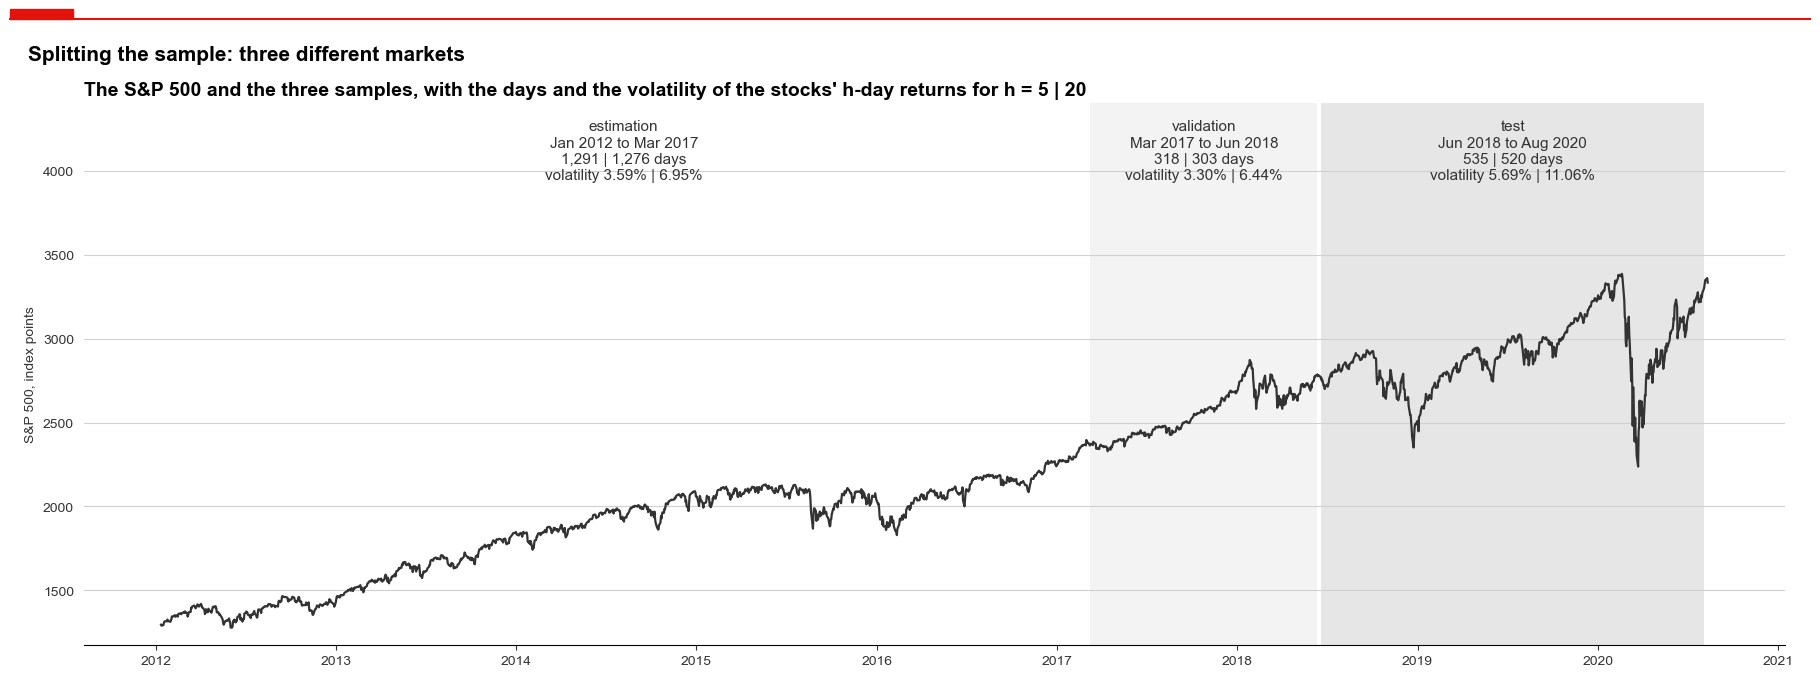

In [212]:
SAMPLES = ["estimation", "validation", "test"]


def describe(mask, y):
    '''First and last day, number of days and volatility of the h-day returns of one sample.'''
    days = dates[mask]
    return {"first": days[0], "last": days[-1], "days": days.nunique(), "volatility": y[mask].std()}


samples = pd.DataFrame({(h, name): describe(mask, y)
                        for h, (X, y, masks) in data.items() for name, mask in masks.items()}).T

fig, ax = plt.subplots(figsize=(18, 6.5))
index_level = market_close.loc[SAMPLE_START:SAMPLE_END]
ax.plot(index_level.index, index_level, color=DARK, lw=1.6)
for name, shade in zip(SAMPLES, ["white", "#F3F3F3", "#E6E6E6"]):
    first, last = samples.loc[(HORIZONS[0], name), ["first", "last"]]
    ax.axvspan(first, last, color=shade, lw=0, zorder=0)
    days = " | ".join(f"{samples.loc[(h, name), 'days']:,}" for h in HORIZONS)
    volatility = " | ".join(f"{samples.loc[(h, name), 'volatility']:.2%}" for h in HORIZONS)
    ax.text(first + (last - first) / 2, 0.97,
            f"{name}\n{first:%b %Y} to {last:%b %Y}\n{days} days\nvolatility {volatility}",
            transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=11, color=DARK)
ax.set_ylim(top=index_level.max() * 1.3)                                  # room for the labels
ax.set_title("The S&P 500 and the three samples, with the days and the volatility of the stocks' h-day returns "
             "for h = 5 | 20")
ax.set_ylabel("S&P 500, index points")
ax.grid(False, axis="x")
show("Splitting the sample: three different markets")

**Comments – 2.2**

- **Three different markets:** a steady bull market in estimation (January 2012 to March 2017), the calmest sample in validation (March 2017 to June 2018, a 5-day volatility of 3.30%) and in the test (June 2018 to August 2020) the sell-off of December 2018 and the COVID crash, with a 5-day volatility of 5.69%, almost 60% above estimation (3.59%). The models are judged in a market unlike the one they learned from, which delivers a ultimative test.
- **Overlap:** 20-day returns of consecutive days share 19 of their 20 days, so the 520 test days of the 20-day horizon hold only 26 non-overlapping months.

### 2.3 How we measure performance
- **$R^2_{OOS}$ of Gu et al. (2020, eq. 19)**, pooled over stocks and test days: $R^2_{OOS} = 1 - \sum (r_{i,t} - \hat r_{i,t})^2 / \sum r_{i,t}^2$. Its benchmark is a forecast of zero, as a single stock's historical mean is too noisy to be a meaningful one.
- **RMSE**, the root mean squared error: on the same days it ranks models as $R^2_{OOS}$ does, but reads as a typical error in percent.
- **Hit rate**, the share of stock-days whose forecast and return have the same sign.
- **Rank IC**, the information coefficient (Grinold and Kahn, 2000) in its rank form, so that a few extreme returns cannot dominate it: each day the Spearman correlation across stocks between forecasts and realised returns, averaged over the days (0 = a random ranking, as on a day the forecasts give every stock the same value). It judges only what a long-short portfolio needs, the ranking of stocks, and ignores the average return and the level of the market. Its **ICIR**, the average divided by the standard deviation over the days, measures how stable that ranking is.

Task #4 adds the economic measure, the Sharpe ratio of the portfolios built on the forecasts. Once 2.4 has shown the weaknesses of $R^2_{OOS}$, we benchmark only with the rank IC and the Sharpe ratio.

In [213]:
def r2_oos(y, prediction):
    '''Out-of-sample R2 of Gu et al. (2020, eq. 19): the benchmark is a forecast of zero.'''
    return 1 - np.sum((y - prediction) ** 2) / np.sum(y ** 2)


def rmse(y, prediction):
    '''Root mean squared error of a forecast.'''
    return np.sqrt(np.mean((y - prediction) ** 2))


def evaluate(y, prediction):
    '''R2_OOS, RMSE and hit rate of one forecast.'''
    return {"R2_OOS": r2_oos(y, prediction), "RMSE": rmse(y, prediction),
            "hit rate": np.mean(np.sign(prediction) == np.sign(y))}


def results(models):
    '''Test performance of the models, one row per horizon and model.'''
    rows = {}
    for h, (X, y, masks) in data.items():
        test = masks["test"]
        for model in models:
            rows[(f"{h}-day", model)] = evaluate(y[test], forecasts[h][model])
    return pd.DataFrame(rows).T


METRIC_FORMAT = {"R2_OOS": "{:.2%}", "RMSE": "{:.2%}", "hit rate": "{:.1%}"}

### 2.4 OLS and Ridge on the four base signals
Ridge adds the penalty (sklearn convention) $\alpha \sum_k \beta_k^2$ to the squared errors and shrinks the slopes towards zero: as $\alpha \to \infty$ it becomes the **training mean**, the average estimation-day return forecast for every stock-day, our naive benchmark. We keep the best of 17 penalties from $10^1$ (almost OLS) to $10^9$ (almost the constant) on the validation days.

In [214]:
ALPHAS = np.logspace(1, 9, 17)              # Ridge penalties, from almost OLS to almost a constant


def ridge_path(X, y, masks, signals):
    '''Validation R2_OOS and coefficients of Ridge for every penalty, estimated on the estimation days.'''
    estimation, validation = masks["estimation"], masks["validation"]
    path = {}
    for alpha in ALPHAS:
        ridge = Ridge(alpha=alpha).fit(X.loc[estimation, signals], y[estimation])
        r2 = r2_oos(y[validation], ridge.predict(X.loc[validation, signals]))
        path[alpha] = {"validation R2": r2, **dict(zip(signals, ridge.coef_))}
    return pd.DataFrame(path).T


def fit_linear(horizon, signals, label):
    '''
    OLS and the validated Ridge for one horizon.
    Their test forecasts go to `forecasts`, the Ridge path is returned.
    '''
    X, y, masks = data[horizon]
    estimation, test = masks["estimation"], masks["test"]
    path = ridge_path(X, y, masks, signals)
    best_alpha = path["validation R2"].idxmax()
    for name, model in [("OLS", LinearRegression()), ("Ridge", Ridge(alpha=best_alpha))]:
        model.fit(X.loc[estimation, signals], y[estimation])
        forecasts[horizon][f"{name} ({label})"] = model.predict(X.loc[test, signals])
    return path

In [215]:
# horizon: {model: its forecasts for the test days}, filled by every model from here to Task #3.
# It starts with the naive benchmark, the average return of the estimation days.
forecasts = {h: {"training mean": np.full(masks["test"].sum(), y[masks["estimation"]].mean())}
             for h, (X, y, masks) in data.items()}
ridge_base = {h: fit_linear(h, BASE, "4 signals") for h in HORIZONS}

linear = results(["training mean", "OLS (4 signals)", "Ridge (4 signals)"])
for h, path in ridge_base.items():
    gain = path["validation R2"].max() - path["validation R2"].iloc[0]     # against the smallest penalty, almost OLS
    print(f"{h}-day horizon: Ridge penalty chosen on the validation days: {path['validation R2'].idxmax():.0e}, "
          f"validation R2_OOS {gain:+.4%} against OLS")
linear.style.format(METRIC_FORMAT, na_rep="")

5-day horizon: Ridge penalty chosen on the validation days: 3e+05, validation R2_OOS +0.0036% against OLS
20-day horizon: Ridge penalty chosen on the validation days: 1e+01, validation R2_OOS +0.0000% against OLS


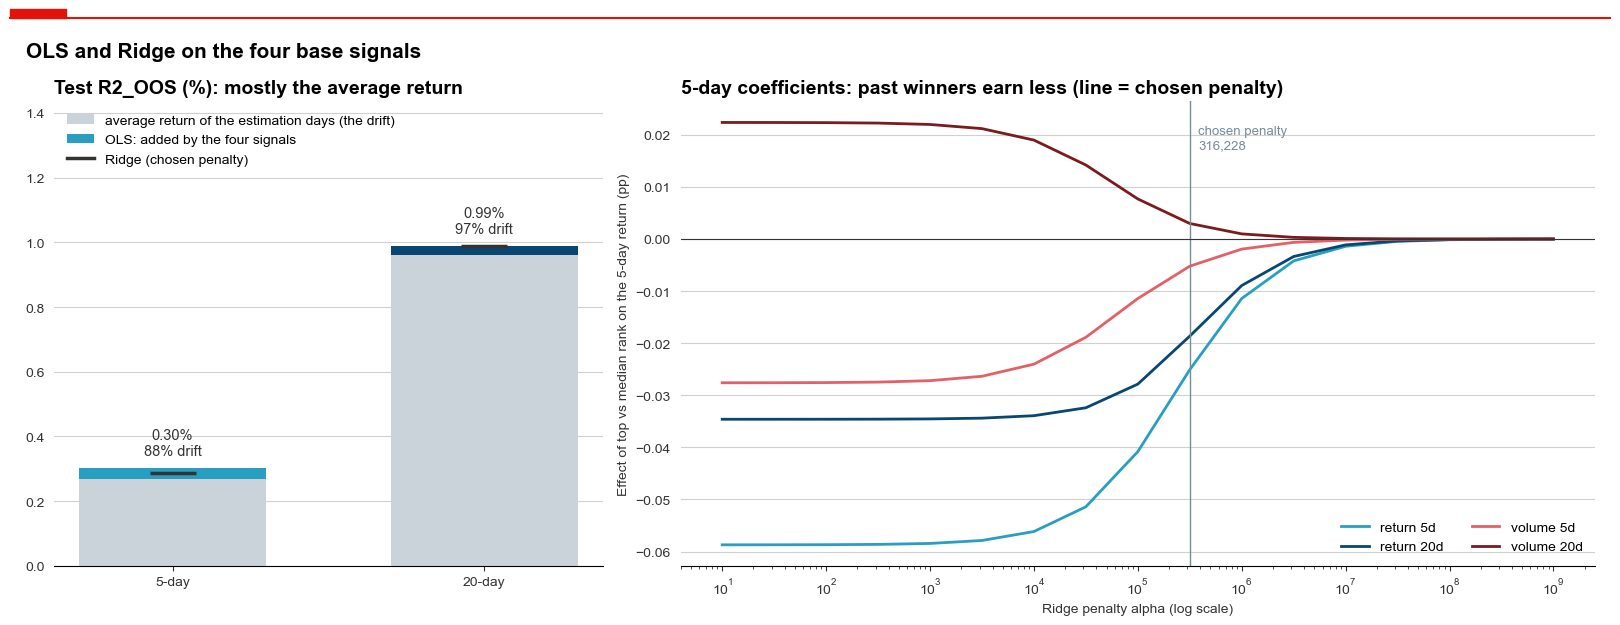

In [216]:
HORIZON_COLORS = dict(zip(HORIZONS, ECONOMIST_BLUES([0.45, 0.85])))   # darker = longer horizon (used to the end)
ECONOMIST_REDS = LinearSegmentedColormap.from_list("economist_reds", ["#F08A8E", "#DB444B", "#7A1B1E"])
RETURN_COLORS = ECONOMIST_BLUES(np.linspace(0.45, 0.85, len(WINDOWS)))     # one per look-back window
VOLUME_COLORS = ECONOMIST_REDS(np.linspace(0.3, 1.0, len(WINDOWS)))

fig, (bars, paths) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [0.6, 1]})

# left: the test R2_OOS of OLS, split into the training mean (the drift) and what the signals add
test_r2 = {model: np.array([linear.loc[(f"{h}-day", model), "R2_OOS"] for h in HORIZONS]) * 100
           for model in ["training mean", "OLS (4 signals)", "Ridge (4 signals)"]}
drift, ols_r2, ridge_r2 = test_r2.values()
positions = np.arange(len(HORIZONS))
drift_bars = bars.bar(positions, drift, width=0.6, color=LIGHT_GREY)
signal_bars = bars.bar(positions, ols_r2 - drift, bottom=drift, width=0.6, color=[HORIZON_COLORS[h] for h in HORIZONS])
bars.scatter(positions, ridge_r2, marker="_", s=1100, linewidths=2.5, color=DARK, zorder=3)
for x, part, total in zip(positions, drift, ols_r2):
    annotate(bars, f"{total:.2f}%\n{part / total:.0%} drift", (x, total), offset=(0, 9), va="baseline", fontsize=10.5)
bars.set_xticks(positions, [f"{h}-day" for h in HORIZONS])
bars.set_ylim(0, ols_r2.max() * 1.45)
bars.set_title("Test R2_OOS (%): mostly the average return")
bars.legend([drift_bars, signal_bars, plt.Line2D([], [], color=DARK, lw=2.5)],
            ["average return of the estimation days (the drift)", "OLS: added by the four signals",
             "Ridge (chosen penalty)"], loc="upper left", fontsize=10)

# right: the 5-day Ridge coefficients along the penalty
path = ridge_base[5]
chosen = path["validation R2"].idxmax()                                   # the penalty the validation days chose
for signal, color in zip(BASE, list(RETURN_COLORS) + list(VOLUME_COLORS)):
    paths.plot(path.index, path[signal] * 100, color=color, lw=2, label=signal)
paths.axvline(chosen, color=GREY, lw=1)
annotate(paths, f"chosen penalty\n{chosen:,.0f}", (chosen, 0.95), xycoords=("data", "axes fraction"),
         offset=(6, 0), va="top", color=GREY)                             
paths.axhline(0, color=DARK, lw=0.8)
paths.set_xscale("log")
paths.set_xlabel("Ridge penalty alpha (log scale)")
paths.set_title("5-day coefficients: past winners earn less (line = chosen penalty)")
paths.set_ylabel("Effect of top vs median rank on the 5-day return (pp)")
paths.legend(loc="lower right", ncol=2, fontsize=10)

for ax in (bars, paths):
    ax.grid(False, axis="x")
show("OLS and Ridge on the four base signals")

**Comments – Task #2**

- **$R^2_{OOS}$ is positive but almost all average return** (left): OLS reaches 0.30% and 0.99% (5 and 20 days), the training mean alone 0.27% and 0.96%.
- **Ridge barely matters:** the validation days pick the smallest penalty at 20 days, so Ridge equals OLS, and 300,000 at 5 days, which gains 0.004 pp on the validation days and loses 0.02 pp on the test days. Shrinkage pays with many signals, as in Gu et al. (2020), not with four coefficients and half a million stock-days.
- **The coefficients show short-term reversal** (right): last week's top stock is expected to earn 0.06 pp less than the median stock next week (Jegadeesh, 1990), against a 5-day volatility of 5.69%.

**Is $R^2_{OOS}$ a good metric?** To compare forecasts on the same test days, yes. As a measure of skill, no: (1) the zero benchmark lets the average return pass for skill, 88% and 97% of OLS's $R^2_{OOS}$; (2) a few volatile days dominate the squared errors; (3) it punishes the size of forecasts, not only their order, so a model that ranks stocks well can still score below zero. 

Using RMSE doesn't help either: built on the same squared errors, it ranks models as $R^2_{OOS}$ does (2.3) and shares all three weaknesses. The hit rate only shows that every forecast is positive: it equals the share of positive returns (55.8% and 59.4%). From here on we therefore benchmark with two measures only: the rank IC, which judges the ranking of stocks a portfolio needs and avoids all three weaknesses (it ignores the average return, weighs every day equally and ignores the size of the forecasts), and the Sharpe ratio of the portfolios built on the forecasts (Task #4, Conclusion).

## Task #2 bis – Improving the model?
We add eight signals in two groups: 
- **The market**, "closer to the theory": the S&P 500's return over the past 5 and 20 days, together with the one-year **beta** of PC Lab #2.
- **More price and volume signals** from the groups that dominate in Gu et al. (2020, Figure 5): 20-day **volatility** and **maximum daily return**, the distance to the **52-week high**, **dollar volume** and the **range position**.

The table below gives each one's definition and why it may predict returns:

| Signal | Definition | Why it may predict returns | Source |
|:---|:---|:---|:---|
| **Beta** | One-year covariance with the S&P 500 / variance of the S&P 500 | Under the CAPM a predictable market return moves each stock in proportion to its beta, so beta enters next to the market's past returns | CAPM, PC Lab #2 |
| **Volatility 20d** | Standard deviation of daily returns, past 20 days | Investors overpay for lottery-like stocks, which then earn lower returns | Bali, Cakici and Whitelaw (2011) |
| **Max return 20d** | Largest daily return, past 20 days | Same mechanism: extreme daily jumps attract investors who overpay | Bali, Cakici and Whitelaw (2011) |
| **52-week high** | Close / highest close of the past year | Investors anchor on the 52-week high and react slowly to good news near it, so stocks close to it tend to keep rising | George and Hwang (2004) |
| **Dollar volume 20d** | Log of average price × volume, past 20 days | Illiquid stocks are costly to trade, so investors demand higher returns. Low dollar volume marks illiquidity | Amihud and Mendelson (1986) |
| **Range position 20d** | (Close − 20-day low) / (20-day high − 20-day low) | A close near the top of the recent range signals buying pressure, a short-term pattern visible in the price charts Jiang et al. feed their network | Jiang et al. (2023) |

The tweets of PC Lab #3 stay out: they cover 25 symbols, not 485, and did not predict returns there. 

In [217]:
def daily_rank_ic(y, prediction, days):
    '''
    Each day's Spearman correlation across stocks between forecasts and realised returns;
    0 on a day the forecasts rank no stock.
    '''
    frame = pd.DataFrame({"forecast": np.asarray(prediction, dtype=float), "realised": np.asarray(y, dtype=float)})
    day = np.asarray(days)
    ranks = frame.groupby(day).rank()
    ranks -= ranks.groupby(day).transform("mean")           # demeaned: their normalised product is the correlation
    product = (ranks["forecast"] * ranks["realised"]).groupby(day).sum()
    squares = (ranks ** 2).groupby(day).sum()
    correlation = product / np.sqrt(squares["forecast"] * squares["realised"])
    return correlation.fillna(0.0)                          # the same forecast for every stock: no ranking


def rank_ic(y, prediction, days):
    '''
    Average daily rank IC and its ICIR (average / standard deviation over the days;
    0 for forecasts that never rank).
    '''
    daily = daily_rank_ic(y, prediction, days)
    return daily.mean(), (daily.mean() / daily.std() if daily.std() > 0 else 0.0)

In [218]:
SETS = {"4 base signals": BASE, "+ market": BASE + MARKET_SIGNALS, "+ 6 stock signals": STOCK_SIGNALS,
        "all 12 signals": ALL_SIGNALS}
COVID = (pd.Timestamp("2020-02-01"), pd.Timestamp("2020-05-31"))      # the crash and the rebound
SUBSAMPLES = ["validation days", "test days", "test days without Feb-May 2020"]

by_set = {}                                                           # OLS on every signal set: rank IC by subsample
for h, (X, y, masks) in data.items():
    estimation, validation, test = masks["estimation"], masks["validation"], masks["test"]
    calm = test & ~((dates >= COVID[0]) & (dates <= COVID[1]))
    subsamples = dict(zip(SUBSAMPLES, [validation, test, calm]))
    for name, signals in SETS.items():
        predicted = LinearRegression().fit(X.loc[estimation, signals], y[estimation]).predict(X[signals])
        by_set[(h, name)] = {sample: rank_ic(y[mask], predicted[mask], dates[mask])[0]
                             for sample, mask in subsamples.items()}
by_set = pd.DataFrame(by_set).T

ridge_all = {h: fit_linear(h, ALL_SIGNALS, "12 signals") for h in HORIZONS}   # Task #3's linear benchmarks

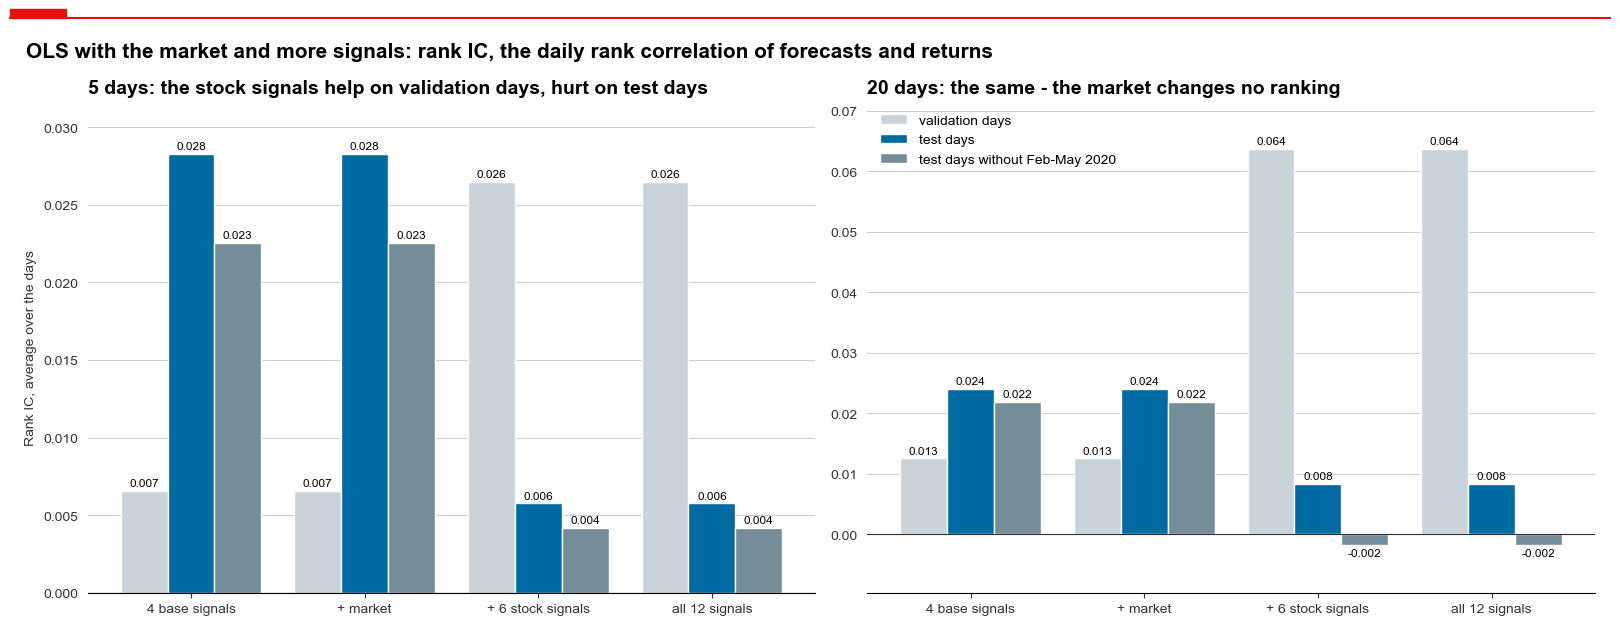

In [219]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(16, 6))
titles = {5: "5 days: the stock signals help on validation days, hurt on test days",
          20: "20 days: the same - the market changes no ranking"}
for ax, h in zip(axes, HORIZONS):
    part = by_set.xs(h, level=0)
    positions = np.arange(len(part))
    for i, (column, color) in enumerate(zip(SUBSAMPLES, [LIGHT_GREY, ECONOMIST_COLORS[0], GREY])):
        bars = ax.bar(positions + (i - 1) * 0.27, part[column], width=0.27, color=color, edgecolor="white",
                      linewidth=1, label=column)
        ax.bar_label(bars, fmt="%.3f", fontsize=8.5, padding=2)
    ax.axhline(0, color=DARK, lw=0.8)
    ax.set_xticks(positions, part.index)
    ax.set_title(titles[h])
    ax.margins(y=0.12)
    ax.grid(False, axis="x")
axes[0].set_ylabel("Rank IC, average over the days")
axes[1].legend(loc="upper left", fontsize=10)
show("OLS with the market and more signals: rank IC, the daily rank correlation of forecasts and returns")

| Set | Signals |
|:---|:---|
| **4 base signals** | return 5d, return 20d, volume 5d, volume 20d |
| **+ market** | the 4 base signals + market 5d, market 20d |
| **+ 6 stock signals** | the 4 base signals + beta, volatility 20d, max return 20d, 52-week high, range position 20d, dollar volume 20d (no market signals) |
| **all 12 signals** | the 4 base signals + the 2 market signals + the 6 stock signals |

**Comments – Task #2 bis**

- **The market does not change the ranking.** The S&P 500's past return is the same number for every stock on a given day. In a linear model it therefore shifts all forecasts of that day by the same amount, and the order of the stocks stays the same. So the rank IC is identical with and without the market (0.028 at 5 days and 0.024 at 20 days on the test days). Only a nonlinear model can combine the market with each stock's beta (tested in 3.4).
- **The six stock signals help on the validation days but hurt on the test days.** On the validation days they raise the rank IC from 0.007 to 0.026 (5 days) and from 0.013 to 0.064 (20 days). On the test days they lower it from 0.028 to 0.006 and from 0.024 to 0.008.
- **COVID does not explain this.** Without February to May 2020, the six stock signals still rank far worse than the four base signals on the test days: 0.004 against 0.023 (5 days) and −0.002 against 0.022 (20 days). What ranked stocks in the calm market of 2017-18 failed in 2018-20.
- **For Task #3 we keep all 12 signals.** They were the best set on the validation days, which is how Gu et al. choose. On the test days the four base signals ranked stocks better, but choosing by test results would be hindsight.

## Task #3 – Machine learning models
### 3.1 Why these models
A linear model gives each signal the same effect on every stock in every market. The models below, from the families Gu et al. (2020) compare, can learn more, such as a beta that matters more right after a crash. All use the same 12 signals.
- **Elastic net**: a linear model that can switch off signals. The validation days choose how strongly.
- **Bayesian ridge**: a linear model that learns from the data how much to trust the signals, and how uncertain each forecast is.
- **Random forest**: 300 decision trees, each grown on a random part of the data, then averaged. Trees catch thresholds and interactions. Averaging smooths out the noise. The validation days choose the size of the trees and how many signals each split may try.
- **XGBoost**: small trees grown one after another, each correcting the errors of the ones before. The validation days choose their size, number and learning rate.
- **NN3**: Gu et al.'s best model, a small neural network with three hidden layers that can learn smooth interactions, such as beta times the market's recent move. The validation days choose its penalty on large weights and its learning rate.

In [220]:
SEED = 42                # fixed random seed, so every run draws the same numbers (also the Monte Carlo of Task #4)


def validation_ic(prediction, y, masks):
    '''Rank IC of a forecast on the validation days, the criterion of every choice made there.'''
    validation = masks["validation"]
    return rank_ic(y[validation], prediction, dates[validation])[0]


def fit_forest(X, y, masks, signals=ALL_SIGNALS, leaves=(8, 32, 128), shares=(0.25, 0.5, 0.75)):
    '''
    Random forest (LightGBM in random-forest mode): 300 trees, each grown on a random fifth of the estimation days.
    Of the numbers of leaves and shares of the signals tried at each split, the forest with the highest validation
    rank IC wins. Returns it and the validation rank IC of every combination.
    '''
    estimation, validation = masks["estimation"], masks["validation"]
    grid, best = {}, None
    for n in leaves:
        for share in shares:
            forest = lgb.LGBMRegressor(boosting_type="rf", n_estimators=300, num_leaves=n, min_child_samples=2000,
                                       subsample=0.2, subsample_freq=1, feature_fraction_bynode=share,
                                       random_state=SEED, verbose=-1)
            forest.fit(X.loc[estimation, signals], y[estimation])
            grid[(n, share)] = validation_ic(forest.predict(X.loc[validation, signals]), y, masks)
            if grid[(n, share)] >= max(grid.values()):
                best = forest
    return best, grid

In [221]:
EN_ALPHAS = np.logspace(-2, -6, 9)        # elastic-net penalties, from all coefficients at zero to almost OLS
EN_L1_RATIOS = [0.1, 0.5, 0.9]             # share of the lasso in the penalty


def fit_elastic_net(X, y, masks, signals=ALL_SIGNALS):
    '''
    Elastic net with the penalty and lasso share that maximise the validation rank IC
    (each fit starts from the previous one).
    '''
    estimation, validation = masks["estimation"], masks["validation"]
    best_score, best = -np.inf, None
    for l1_ratio in EN_L1_RATIOS:
        model = ElasticNet(l1_ratio=l1_ratio, warm_start=True, max_iter=5000)
        for alpha in EN_ALPHAS:
            model.set_params(alpha=alpha).fit(X.loc[estimation, signals], y[estimation])
            score = validation_ic(model.predict(X.loc[validation, signals]), y, masks)
            if score > best_score:
                best_score, best = score, copy.deepcopy(model)
    return best


def fit_xgboost(X, y, masks, signals=ALL_SIGNALS, depths=(1, 2, 3), rates=(0.01, 0.1),
                trees=(10, 25, 50, 100, 200, 300, 500, 750, 1000)):
    '''XGBoost with the depth, learning rate and number of trees that give the highest validation rank IC.'''
    estimation, validation = masks["estimation"], masks["validation"]
    scores = {}
    for depth in depths:
        for rate in rates:
            booster = xgb.XGBRegressor(n_estimators=max(trees), max_depth=depth, learning_rate=rate,
                                       tree_method="hist", random_state=SEED)
            booster.fit(X.loc[estimation, signals], y[estimation])
            for n in trees:                                          # the first n trees, scored without refitting
                forecast = booster.predict(X.loc[validation, signals], iteration_range=(0, n))
                scores[(depth, rate, n)] = validation_ic(forecast, y, masks)
    depth, rate, n = max(scores, key=scores.get)
    best = xgb.XGBRegressor(n_estimators=n, max_depth=depth, learning_rate=rate, tree_method="hist", random_state=SEED)
    return best.fit(X.loc[estimation, signals], y[estimation])

In [222]:
def nn3(n_inputs=len(ALL_SIGNALS)):
    '''NN3 of Gu et al. (2020): hidden layers of 32, 16 and 8 ReLU neurons, each with batch normalisation.'''
    layers, width = [], n_inputs
    for neurons in [32, 16, 8]:
        layers += [nn.Linear(width, neurons), nn.BatchNorm1d(neurons), nn.ReLU()]
        width = neurons
    return nn.Sequential(*layers, nn.Linear(width, 1))


def train_networks(make, X_fit, y_fit, X_val, y_val, val_days, seeds=range(20), epochs=40, patience=4, batch=2048,
                   lr=1e-3, l1=1e-5):
    '''
    Gu et al. (2020) recipe with Adam and an L1 penalty on the weights;
    each network keeps the epoch with the best validation rank IC.
    '''
    X_fit, y_fit = (torch.as_tensor(np.asarray(a, dtype=np.float32)) for a in (X_fit, y_fit))
    y_val = np.asarray(y_val, dtype=np.float64)
    networks = []
    for seed in seeds:
        torch.manual_seed(seed)
        network = make()
        optimizer = torch.optim.Adam(network.parameters(), lr=lr)
        best_score, waited = -np.inf, 0
        for epoch in range(1, epochs + 1):
            network.train()
            for rows in torch.randperm(len(X_fit)).split(batch):
                loss = nn.functional.mse_loss(network(X_fit[rows]).squeeze(-1), y_fit[rows])
                loss = loss + l1 * sum(w.abs().sum() for name, w in network.named_parameters() if "weight" in name)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            score = rank_ic(y_val, predict([network], X_val), val_days)[0]
            if score > best_score:
                best_score, best_state, waited = score, copy.deepcopy(network.state_dict()), 0
            else:
                waited += 1
                if waited == patience:
                    break
        network.load_state_dict(best_state)
        networks.append(network)
    return networks


def predict(networks, X):
    '''Average forecast of an ensemble of networks.'''
    X = torch.as_tensor(np.asarray(X, dtype=np.float32))
    outputs = []
    for network in networks:
        network.eval()
        with torch.no_grad():
            outputs.append(torch.cat([network(rows).squeeze(-1) for rows in X.split(65_536)]))
    return torch.stack(outputs).mean(0).numpy()

In [223]:
NN_GRID = [(l1, lr) for l1 in (1e-5, 1e-4, 1e-3) for lr in (1e-3, 1e-2)]   # L1 penalty x learning rate (Gu et al.)


def tune_networks(X, y, masks, signals=ALL_SIGNALS, grid=NN_GRID, seeds=range(20), trials=5):
    '''
    NN3 tuned as in Gu et al. (2020): for every L1 penalty and learning rate, 5 networks are trained and the rank IC
    of their average forecast is measured on the validation days. The other 15 networks of the ensemble use the
    best pair. Returns the networks and the grid.
    '''
    estimation, validation = masks["estimation"], masks["validation"]
    samples = (X.loc[estimation, signals], y[estimation], X.loc[validation, signals], y[validation], dates[validation])
    make = lambda: nn3(len(signals))
    networks, scores = {}, {}
    for l1, lr in grid:
        networks[(l1, lr)] = train_networks(make, *samples, seeds=list(seeds)[:trials], lr=lr, l1=l1)
        scores[(l1, lr)] = validation_ic(predict(networks[(l1, lr)], X.loc[validation, signals]), y, masks)
    l1, lr = max(scores, key=scores.get)
    return networks[(l1, lr)] + train_networks(make, *samples, seeds=list(seeds)[trials:], lr=lr, l1=l1), scores

### 3.2 Training
The models minimise squared errors, as in Gu et al. (2020), but every choice made on the validation days follows the rank IC, the measure we benchmark with (2.4). The forest's number of leaves (8, 32 or 128) and share of the signals tried at each split (a quarter, half or three quarters); NN3's L1 penalty ($10^{-5}$, $10^{-4}$ or $10^{-3}$) and learning rate (0.001 or 0.01), each pair scored by the average of 5 networks, and the epoch each network keeps (it stops once its validation rank IC has not improved for 4 epochs); XGBoost's depth (1 to 3), learning rate (0.01 or 0.1) and number of trees (10 to 1,000); the penalties of Ridge and the elastic net. A single network depends on its random start, and a top-10 portfolio on small differences between forecasts, so NN3 averages 20 networks (Gu et al.: 10). For 3.4 every model is re-estimated with the same settings on the 10 stock signals, without the market. Training takes about 12 minutes, so the forecasts of the forest, XGBoost and NN3 are stored on disk: a re-run loads them without PyTorch or LightGBM. The other models take seconds and are fitted on every run.

**How the models learn.** All models minimise squared errors, as in Gu et al. (2020). But every setting is chosen by the rank IC on the validation days, the measure we benchmark with (2.4).

**What the validation days choose:**

| Model | Settings tried |
|:---|:---|
| Random forest | number of leaves (8, 32 or 128)**;** share of the signals tried at each split (a quarter, half or three quarters) |
| XGBoost | depth (1 to 3)**;** learning rate (0.01 or 0.1)**;** number of trees (10 to 1,000) |
| NN3 | L1 penalty ($10^{-5}$, $10^{-4}$ or $10^{-3}$)**;** learning rate (0.001 or 0.01) |
| Ridge, elastic net | the penalty |

**NN3 in detail.** Each pair of L1 penalty and learning rate is scored by the average forecast of 5 networks. Each network stops once its validation rank IC has not improved for 4 epochs, and keeps its best epoch. One network depends on its random start, and a top-10 portfolio depends on small differences between forecasts. So the final NN3 averages 20 networks (Gu et al. use 10).

**For 3.4**, every model is estimated again with the same settings on the 10 stock signals, without the market.

**Caveat: Run time.** Training the forest, XGBoost and NN3 takes about 12 minutes. So their forecasts are stored on disk, and a re-run loads them without PyTorch or LightGBM. The other models take seconds and are fitted on every run.

In [224]:
FORECAST_CACHE = "pclab4_ml_forecasts.npz"
ML_KEYS = {"Random forest": "forest", "XGBoost": "xgb", "NN3": "nn3"}   # names of their forecasts on disk


def train_models():
    '''
    Tune and train the forest, XGBoost and NN3 for every horizon. Returns as named arrays their forecasts for the
    validation and test days, their test forecasts without the market signals (same settings), the tuning grids
    and XGBoost's settings.
    '''
    out = {}
    for h, (X, y, masks) in data.items():
        estimation, validation, test = masks["estimation"], masks["validation"], masks["test"]
        forest, forest_grid = fit_forest(X, y, masks)
        booster = fit_xgboost(X, y, masks)
        networks, nn3_grid = tune_networks(X, y, masks)

        # the same settings on the 10 stock signals, without the market (3.4)
        (n, share), (l1, lr) = max(forest_grid, key=forest_grid.get), max(nn3_grid, key=nn3_grid.get)
        forest_stock = fit_forest(X, y, masks, STOCK_SIGNALS, leaves=[n], shares=[share])[0]
        booster_stock = clone(booster).fit(X.loc[estimation, STOCK_SIGNALS], y[estimation])
        networks_stock = train_networks(lambda: nn3(len(STOCK_SIGNALS)), X.loc[estimation, STOCK_SIGNALS],
                                        y[estimation], X.loc[validation, STOCK_SIGNALS], y[validation],
                                        dates[validation], lr=lr, l1=l1)

        for key, model, model_stock in [("forest", forest.predict, forest_stock.predict),
                                        ("xgb", booster.predict, booster_stock.predict),
                                        ("nn3", lambda Z: predict(networks, Z), lambda Z: predict(networks_stock, Z))]:
            out.update({f"{key}_{h}": model(X.loc[test, ALL_SIGNALS]),
                        f"{key}_validation_{h}": model(X.loc[validation, ALL_SIGNALS]),
                        f"{key}_stock_{h}": model_stock(X.loc[test, STOCK_SIGNALS])})
        used = booster.get_booster().get_score()                             # the signals XGBoost splits on
        out.update({f"forest_grid_{h}": np.array([[a, b, score] for (a, b), score in forest_grid.items()]),
                    f"nn3_grid_{h}": np.array([[a, b, score] for (a, b), score in nn3_grid.items()]),
                    f"xgb_settings_{h}": np.array([booster.max_depth, booster.learning_rate, booster.n_estimators]),
                    f"xgb_signals_{h}": np.array([signal in used for signal in ALL_SIGNALS])})
    return out


def cached_forecasts(train, cache=FORECAST_CACHE):
    '''The trained models' forecasts, stored on disk: training takes minutes, loading a second.'''
    if not os.path.exists(cache):
        np.savez_compressed(cache, **train())
    with np.load(cache) as stored:
        return {key: stored[key] for key in stored.files}


def refit(model, X, y, masks, signals):
    '''The same model with the same settings, estimated on other signals.'''
    return clone(model).fit(X.loc[masks["estimation"], signals], y[masks["estimation"]])

In [225]:
# The forest, XGBoost and NN3: trained once, then loaded from disk.
ml = cached_forecasts(train_models)

# horizon: {model: forecasts}, like 'forecasts': for the validation days (3.3) and without the market signals (3.4)
validation_forecasts, stock_forecasts = {h: {} for h in HORIZONS}, {h: {} for h in HORIZONS}
for h in HORIZONS:
    for name, key in ML_KEYS.items():
        forecasts[h][name] = ml[f"{key}_{h}"]
        validation_forecasts[h][name] = ml[f"{key}_validation_{h}"]
        stock_forecasts[h][name] = ml[f"{key}_stock_{h}"]

In [226]:
# The linear models, the elastic net and Bayesian ridge take seconds, so no need to store them
linear_models = {}                                           # horizon: {model: fitted on all 12 signals}
for h, (X, y, masks) in data.items():
    validation, test = masks["validation"], masks["test"]

    # Ridge's penalty: the validation rank IC of the coefficients 2 bis estimated for every penalty.
    # The intercept is left out: it shifts every forecast of a day alike and changes no ranking.
    path, X_validation = ridge_all[h], X.loc[validation, ALL_SIGNALS].to_numpy()
    alpha = max(path.index, key=lambda a: validation_ic(X_validation @ path.loc[a, ALL_SIGNALS].to_numpy(), y, masks))

    linear_models[h] = {"OLS (12 signals)": refit(LinearRegression(), X, y, masks, ALL_SIGNALS),
                        "Ridge (12 signals)": refit(Ridge(alpha=alpha), X, y, masks, ALL_SIGNALS),
                        "Elastic net": fit_elastic_net(X, y, masks),
                        "Bayesian ridge": refit(BayesianRidge(), X, y, masks, ALL_SIGNALS)}
    for name, model in linear_models[h].items():
        forecasts[h][name] = model.predict(X.loc[test, ALL_SIGNALS])
        validation_forecasts[h][name] = model.predict(X.loc[validation, ALL_SIGNALS])
        stock_forecasts[h][name] = refit(model, X, y, masks, STOCK_SIGNALS).predict(X.loc[test, STOCK_SIGNALS])

In [227]:
# The settings the validation days chose.
for h, (X, y, masks) in data.items():
    forest_grid, nn3_grid = ml[f"forest_grid_{h}"], ml[f"nn3_grid_{h}"]
    (n, share), (l1, lr) = forest_grid[forest_grid[:, 2].argmax(), :2], nn3_grid[nn3_grid[:, 2].argmax(), :2]
    depth, rate, trees = ml[f"xgb_settings_{h}"]
    ridge, enet, bayes = (linear_models[h][name] for name in ["Ridge (12 signals)", "Elastic net", "Bayesian ridge"])

    # Bayesian ridge: a forecast's variance = the noise 1 / alpha_ + what the uncertain coefficients add
    std = bayes.predict(X.loc[masks["test"], ALL_SIGNALS], return_std=True)[1]
    from_coefficients = np.sqrt(np.mean(std ** 2 - 1 / bayes.alpha_))

    indent = " " * len(f"{h}-day horizon")
    print(f"{h}-day horizon | NN3: L1 penalty {l1:.0e}, learning rate {lr:g} "
          f"| forest: {n:.0f} leaves, {share:.0%} of the signals at each split "
          f"| XGBoost: depth {depth:.0f}, learning rate {rate:g}, {trees:.0f} trees, "
          f"splitting on {ml[f'xgb_signals_{h}'].sum()} of {len(ALL_SIGNALS)} signals")
    print(f"{indent} | Ridge: penalty {ridge.alpha:.0e} "
          f"| elastic net: penalty {enet.alpha:.0e}, lasso share {enet.l1_ratio}, "
          f"{np.sum(enet.coef_ != 0)} of {len(ALL_SIGNALS)} signals kept "
          f"| Bayesian ridge: penalty {bayes.lambda_ / bayes.alpha_:.0e}, coefficient uncertainty adds "
          f"{from_coefficients:.3%} to a forecast's standard deviation, the noise {1 / np.sqrt(bayes.alpha_):.2%}")

5-day horizon | NN3: L1 penalty 1e-05, learning rate 0.01 | forest: 32 leaves, 25% of the signals at each split | XGBoost: depth 2, learning rate 0.1, 500 trees, splitting on 12 of 12 signals
              | Ridge: penalty 1e+05 | elastic net: penalty 3e-05, lasso share 0.5, 11 of 12 signals kept | Bayesian ridge: penalty 1e+02, coefficient uncertainty adds 0.020% to a forecast's standard deviation, the noise 3.58%
20-day horizon | NN3: L1 penalty 1e-05, learning rate 0.01 | forest: 8 leaves, 25% of the signals at each split | XGBoost: depth 1, learning rate 0.1, 500 trees, splitting on 11 of 12 signals
               | Ridge: penalty 1e+05 | elastic net: penalty 3e-05, lasso share 0.9, 10 of 12 signals kept | Bayesian ridge: penalty 2e+02, coefficient uncertainty adds 0.038% to a forecast's standard deviation, the noise 6.92%


### 3.3 Results
Every model on the same 12 signals: its rank IC on the test days (coloured dots, with the ICIR) and on the validation days on which its settings were chosen (grey dots). At zero a model ranks the stocks no better than chance.

In [228]:
MODELS = ["OLS (12 signals)", "Ridge (12 signals)", "Elastic net", "Bayesian ridge", "Random forest", "XGBoost", "NN3"]
MODEL_COLORS = {**dict.fromkeys(MODELS[:4], DARK), "Random forest": "#379A8B", "XGBoost": "#379A8B",
                "NN3": ECONOMIST_COLORS[0]}                 # colour = model family (also in 3.4 and the Conclusion)


def rank_ics(source, sample="test"):
    '''Every model's rank IC and ICIR on one sample, from the forecasts in `source`: a frame per horizon.'''
    out = {}
    for h, (X, y, masks) in data.items():
        mask = masks[sample]
        scores = {model: rank_ic(y[mask], source[h][model], dates[mask]) for model in MODELS}
        out[h] = pd.DataFrame(scores, index=["rank IC", "ICIR"]).T
    return out


test_ics, validation_ics = rank_ics(forecasts), rank_ics(validation_forecasts, "validation")

In [229]:
def dumbbells(other, other_label, filled_label, titles, title, xlabel="Rank IC on the test days", grey=False,
              icir=False, **legend):
    '''
    Every model's test rank IC with the forecasts of 3.3 (filled dots) against its rank IC in 'other'
    (hollow dots, or grey ones), one panel per horizon. 'icir' adds the ICIR to the labels of the filled dots.
    Other arguments place the legend.
    '''
    face, edge = (LIGHT_GREY, GREY) if grey else ("white", DARK)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)
    for ax, h in zip(axes, HORIZONS):
        for i, model in enumerate(MODELS):
            color = MODEL_COLORS[model]
            before, after = other[h].loc[model, "rank IC"], test_ics[h].loc[model, "rank IC"]
            ax.plot([before, after], [i, i], color=LIGHT_GREY, lw=3, zorder=1)
            ax.scatter(before, i, s=110, facecolors=face, edgecolors=GREY if grey else color, linewidths=2, zorder=3)
            ax.scatter(after, i, s=110, color=color, zorder=3)

            # a label on the outer side of each dot, or one label if the dots coincide
            suffix = f" (ICIR {test_ics[h].loc[model, 'ICIR']:.2f})" if icir else ""
            ends = sorted([(before, f"{before:.3f}"), (after, f"{after:.3f}{suffix}")])
            if ends[1][0] - ends[0][0] < 0.0005:
                ends = ends[1:]
            for (value, text), side in zip(ends, [-1, 1][-len(ends):]):
                annotate(ax, text, (value, i), offset=(9 * side, 0), bbox=WHITE_BOX)
        ax.axvline(0, color=DARK, lw=1)
        ax.margins(x=0.4 if icir else 0.25)                                   # room for the labels
        ax.set_title(titles[h])
        ax.set_xlabel(xlabel)
        vertical_grid(ax)
    axes[0].set_yticks(np.arange(len(MODELS)), MODELS)
    axes[0].invert_yaxis()
    for tick in axes[0].get_yticklabels():
        tick.set_fontweight("bold" if tick.get_text() == "NN3" else "normal")
    dot = {"marker": "o", "ls": "", "ms": 10}
    handles = [plt.Line2D([], [], markerfacecolor=face, markeredgecolor=edge, markeredgewidth=2, label=other_label,
                          **dot),
               plt.Line2D([], [], color=DARK, label=filled_label, **dot),
               plt.Line2D([], [], color=DARK, lw=1, label="0 = random ranking")]
    axes[1].legend(handles=handles, fontsize=10, **(legend or {"loc": "upper right"}))
    show(title)

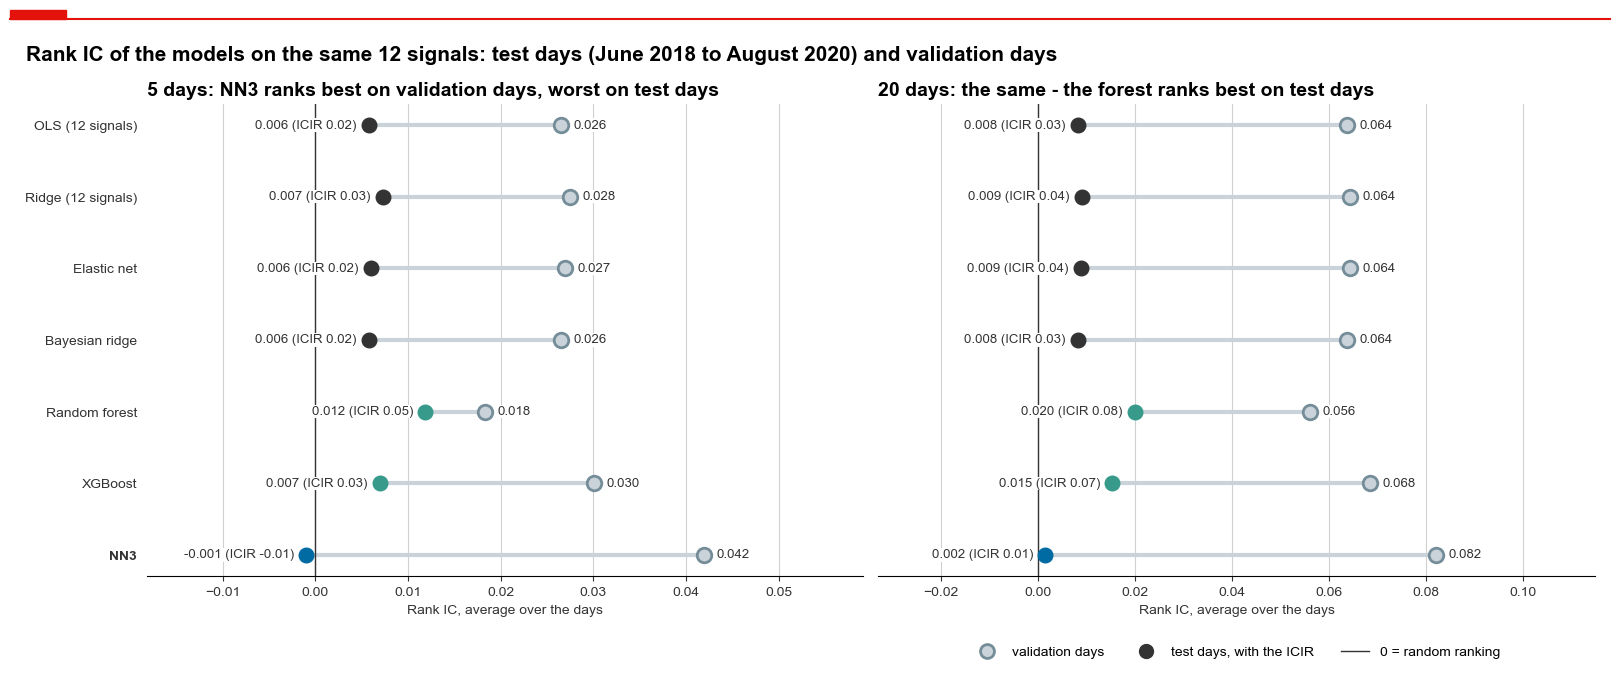

In [230]:
dumbbells(validation_ics, "validation days", "test days, with the ICIR", grey=True, icir=True,
          titles={5: "5 days: NN3 ranks best on validation days, worst on test days",
                  20: "20 days: the same - the forest ranks best on test days"},
          title="Rank IC of the models on the same 12 signals: test days (June 2018 to August 2020) "
                "and validation days",
          xlabel="Rank IC, average over the days", loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)

**Main point.** No model ranks the stocks much better than chance on the test days: the best rank IC is 0.020. The validation days also misled us. NN3 ranked best there at both horizons, but worst on the test days. Th Random forest ranks best on test days.

In [231]:
# Test R2_OOS on all 12 signals and without the two market signals.
r2 = {}
for h, (X, y, masks) in data.items():
    test = masks["test"]
    for label, source in [("12 signals", forecasts), ("10 stock signals", stock_forecasts)]:
        r2[(f"{h}-day", label)] = {model: r2_oos(y[test], source[h][model]) for model in MODELS}
pd.DataFrame(r2).style.format("{:.2%}")

**$R^2_{OOS}$ tells a different story, and it is the market's.** At 5 days only Ridge stays positive (0.23%) and NN3 is lowest (−1.07%). At 20 days every model beats the training mean (0.96%), the elastic net and OLS most (2.01% and 1.99%). Without the two market signals every model falls back to the average return (0.23% to 0.33% at 5 days, 0.79% to 1.15% at 20 days). $R^2_{OOS}$ here measures a bet on the market's level, which lost at 5 days and paid at 20 days. It ranks no stock, so we keep the rank IC.

### 3.4 Do the models need the market signals?
In task #2 bis we argued that the S&P 500's past returns can only change the ranking of stocks through a nonlinear model. Each model is therefore re-estimated with the same settings on the 10 stock signals alone (hollow dots) and compared with its forecasts on all 12 signals (filled dots): rank IC on the test days.

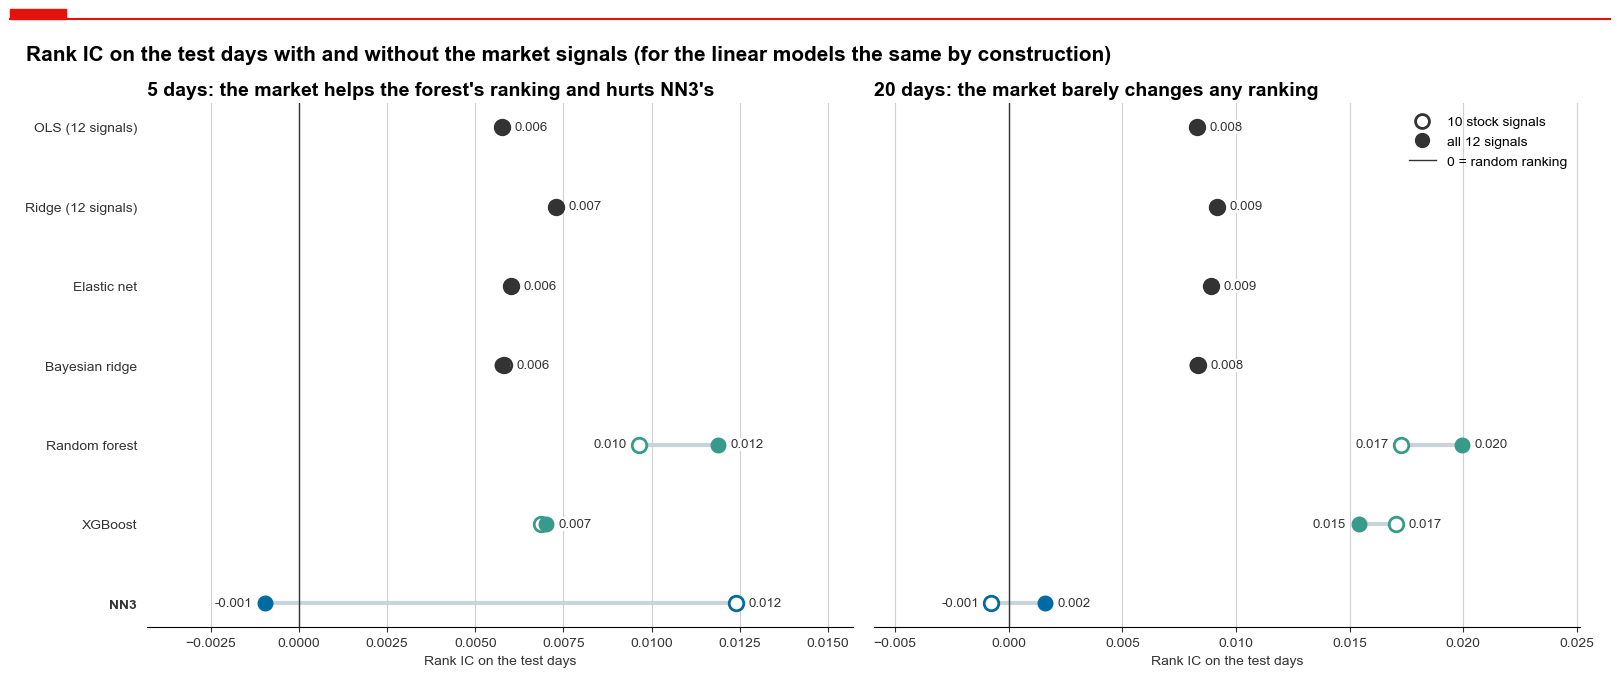

In [232]:
dumbbells(rank_ics(stock_forecasts), "10 stock signals", "all 12 signals",
          titles={5: "5 days: the market helps the forest's ranking and hurts NN3's",
                  20: "20 days: the market barely changes any ranking"},
          title="Rank IC on the test days with and without the market signals "
                "(for the linear models the same by construction)")

**Main point.** The models hardly need the market signals: with them only the forest ranks a little better at both horizons, while NN3 ranks clearly worse at 5 days.

### 3.5 Would re-estimating every year help?
So far each model is estimated once, on 2012 to 2017, and then forecasts the whole test period. Gu et al. (2020) instead re-estimate their models every year. We test whether that helps us:
- **June to December 2018:** the forecasts of 3.2.
- **2019:** the models are re-estimated at the start of 2019, with data up to the end of 2018.
- **2020:** the models are re-estimated at the start of 2020, with data up to the end of 2019.

We keep the settings of 3.2, so only the data change. The validation days move forward with each re-estimation: same length, ending $h$ days before the new year. The networks again keep the epoch with the best validation rank IC. Re-estimating the forest, XGBoost and NN3 takes about 10 minutes, so the forecasts are stored on disk, as in 3.2.

In [233]:
YEARLY_CACHE = "pclab4_yearly_forecasts.npz"
REFIT_YEARS = [2019, 2020]                       # each later test year starts with a re-estimation


def yearly_masks(h, year):
    '''
    Estimation and validation days of the re-estimation at the start of `year`;
    the validation days keep their length (2.2).
    '''
    t = trading_days.searchsorted(pd.Timestamp(year, 1, 1))                 # the year's first trading day
    n_valid = int(int(len(trading_days) * TRAIN_SHARE) * VALID_SHARE)
    observed = ~np.isnan(data[h][1])
    return {"estimation": dates.isin(trading_days[:t - n_valid - h]) & observed,
            "validation": dates.isin(trading_days[t - n_valid:t - h]) & observed}


def train_yearly():
    '''
    Re-estimate the forest, XGBoost and NN3 at the start of every year of REFIT_YEARS with the settings of 3.2;
    return their forecasts of that year.
    '''
    out = {}
    for h, (X, y, masks) in data.items():
        forest_grid, nn3_grid = ml[f"forest_grid_{h}"], ml[f"nn3_grid_{h}"]
        (n, share), (l1, lr) = forest_grid[forest_grid[:, 2].argmax(), :2], nn3_grid[nn3_grid[:, 2].argmax(), :2]
        depth, rate, trees = ml[f"xgb_settings_{h}"]
        for year in REFIT_YEARS:
            refit_masks = yearly_masks(h, year)
            estimation, validation = refit_masks["estimation"], refit_masks["validation"]
            forest = fit_forest(X, y, refit_masks, leaves=[int(n)], shares=[share])[0]
            booster = xgb.XGBRegressor(n_estimators=int(trees), max_depth=int(depth), learning_rate=rate,
                                       tree_method="hist", random_state=SEED)
            booster.fit(X.loc[estimation, ALL_SIGNALS], y[estimation])
            networks = train_networks(nn3, X.loc[estimation, ALL_SIGNALS], y[estimation],
                                      X.loc[validation, ALL_SIGNALS], y[validation], dates[validation], lr=lr, l1=l1)
            days = masks["test"] & (dates.year == year)
            for key, model in [("forest", forest.predict), ("xgb", booster.predict),
                               ("nn3", lambda Z: predict(networks, Z))]:
                out[f"{key}_{h}_{year}"] = model(X.loc[days, ALL_SIGNALS])
    return out

In [234]:
yearly = cached_forecasts(train_yearly, YEARLY_CACHE)

yearly_forecasts = {h: {} for h in HORIZONS}                 # the forecasts of 3.2, replaced from 2019 on
for h, (X, y, masks) in data.items():
    test = masks["test"]
    for model in MODELS:
        combined = forecasts[h][model].copy()                      # until the end of 2018: the forecasts of 3.2
        for year in REFIT_YEARS:
            days = dates.year == year
            if model in ML_KEYS:
                combined[days[test]] = yearly[f"{ML_KEYS[model]}_{h}_{year}"]
            else:                                                  # the linear models take seconds: fitted on every run
                refitted = refit(linear_models[h][model], X, y, yearly_masks(h, year), ALL_SIGNALS)
                combined[days[test]] = refitted.predict(X.loc[test & days, ALL_SIGNALS])
        yearly_forecasts[h][model] = combined

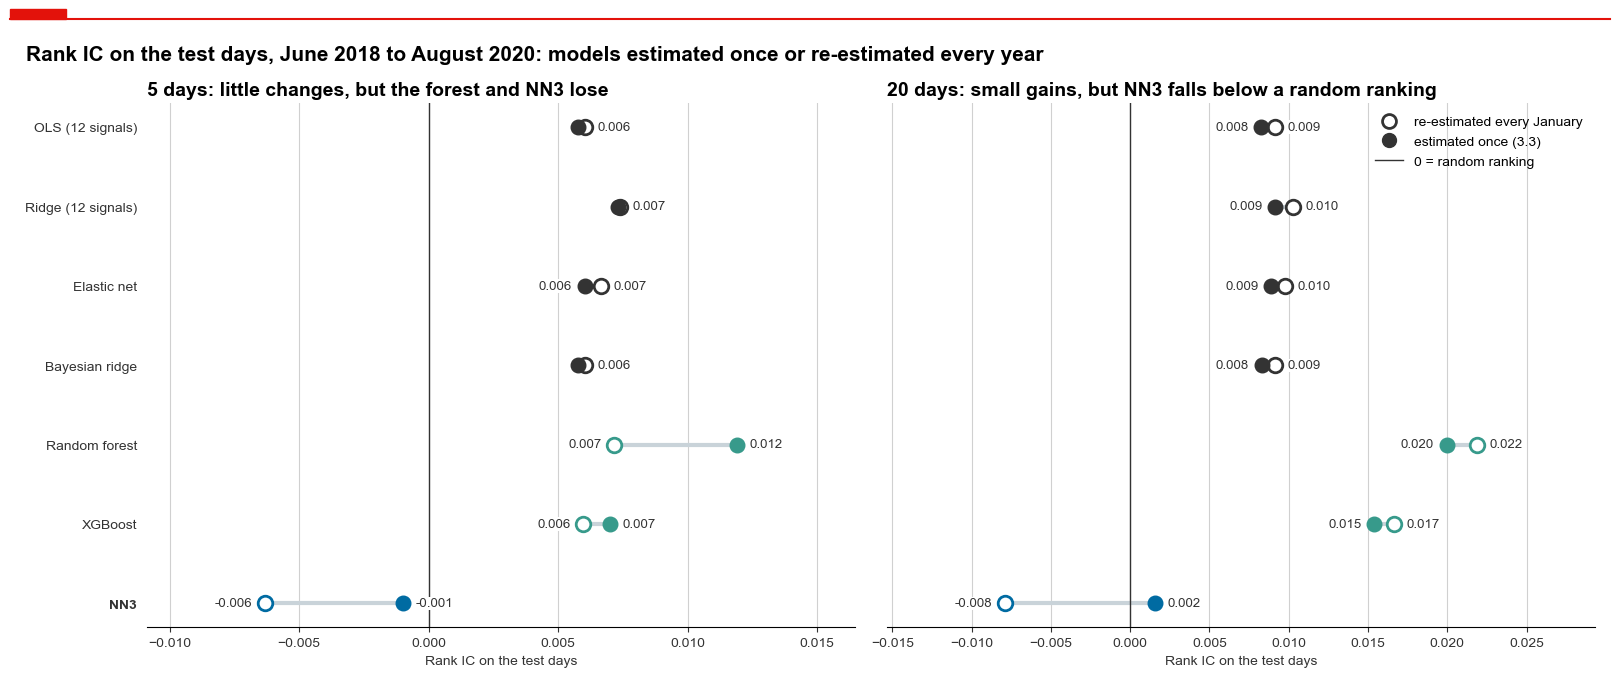

In [235]:
dumbbells(rank_ics(yearly_forecasts), "re-estimated every January", "estimated once (3.3)",
          titles={5: "5 days: little changes, but the forest and NN3 lose",
                  20: "20 days: small gains, but NN3 falls below a random ranking"},
          title="Rank IC on the test days, June 2018 to August 2020: models estimated once or re-estimated every year")

In [236]:
print("Rank IC of the test days by year, average of the seven models: estimated once -> re-estimated every January")
for h, (X, y, masks) in data.items():
    test = masks["test"]
    by_year = {}
    for name, source in [("once", forecasts), ("every year", yearly_forecasts)]:
        of_models = [daily_rank_ic(y[test], source[h][model], dates[test]) for model in MODELS]
        daily = pd.concat(of_models, axis=1).mean(axis=1)
        by_year[name] = daily.groupby(daily.index.year).mean()
    once, every_year = by_year["once"], by_year["every year"]
    print(f"{h:>2} days: 2018 {once[2018]:.3f} | "
          + " | ".join(f"{year} {once[year]:.3f} -> {every_year[year]:.3f}" for year in REFIT_YEARS))

Rank IC of the test days by year, average of the seven models: estimated once -> re-estimated every January
 5 days: 2018 -0.011 | 2019 0.027 -> 0.029 | 2020 -0.015 -> -0.023
20 days: 2018 -0.043 | 2019 0.060 -> 0.059 | 2020 -0.031 -> -0.030


**Comments – Task #3**

**Answer 1 – Which method performs best? None ranks stocks well. The forest does least badly.**
- **On the test days the forest ranks best** (rank IC 0.012 at 5 days, 0.020 at 20 days), XGBoost follows at 20 days (0.015), the linear models stay below 0.01, and NN3 ranks no better than chance (−0.001 and 0.002). All are unstable, and none reaches the four base signals of Task #2 (0.028 and 0.024).
- **The validation days pointed the other way** (3.3): there NN3 ranked best at both horizons (0.042 and 0.082), as Gu et al. would expect, and every model ranked far better than on the test days, the forest least so. What the calm days of 2017-18 rewarded carried over poorly to 2018-20. This makes a case that good performance does not imply good generalization.
- **What the validation days chose.** NN3: the smallest L1 penalty and a learning rate of 0.01, at both horizons. Forest: small trees (32 leaves at 5 days, 8 at 20 days), each split trying a quarter of the signals. XGBoost: 500 trees at both horizons, using 12 and 11 of the 12 signals. Choosing by the rank IC matches how we judge the models. But one short validation period makes the choice noisy: NN3, rated best there, ranked worst on the test days at both horizons.

**Why does NN3 rank so poorly? Probably its flexibility goes into the market, not into the stocks.** A network can bend its response to extreme market moves such as the COVID crash and rebound, which the calm estimation years barely contain. That times the market's level but ranks no stock. 3.4 shows it: with the market signals NN3 ranks worse at 5 days (−0.001 against 0.012 without), while XGBoost barely changes (0.007 either way). The forest gains a little from the market at both horizons (0.010 to 0.012 and 0.017 to 0.020), the interaction 2 bis asked for.

**Would re-estimating every year help? No** (3.5). Most models change by at most 0.002, and the forest at 5 days (0.012 to 0.007) and NN3 at both horizons (−0.001 to −0.006 and 0.002 to −0.008) lose. The year matters far more than the estimation: on average the seven models rank well in 2019 (0.027 and 0.060) and worse than chance in 2018 and 2020 (down to −0.043), a swing that re-estimating on past data cannot anticipate.

**Comparable with Gu et al.? Hardly**: they find networks best in both $R^2_{OOS}$ and portfolio returns, with 920 signals for nearly 30,000 stocks and 30 test years. We have 12 price and volume signals of 481 large stocks and 2.2 test years with one crash. By $R^2_{OOS}$ our 20-day NN3 (1.70%) even exceeds their monthly NN3 (0.40%), but 0.96 pp of ours is the average return and the rest comes from the market signals.

**Answer 2 – What about Jiang et al. (2023)?** Their network reads images of 20 days of prices and volumes and finds strong weekly predictability across all US stocks, but much less among the 500 largest. We use their information set and one of their patterns, the range position, not their network: among large stocks their own results leave little to find, and our rank ICs confirm that prices and volumes say little about which large stock will beat which.





 

## Task #4 – Performance of the ML-driven portfolio
Our ML model is chosen like every setting before it: by the rank IC on the validation days. That is **NN3** at both horizons (3.3), also Gu et al.'s best model. The forest ranks best on the test days, but choosing by the test period's results would let us fall for the Look-ahead-bias. The Conclusion shows what every model's portfolio would have earned. From the first test day (20 June 2018), every $h$ days we buy in equal weights the 10 S&P 500 stocks with the highest forecast and hold them for $h$ days. With about 470 stocks instead of the lab's eight, 10 spread the bet better than the slides' 4. 

One function, `simulate`, values both the ML and the random portfolios, so they are treated exactly alike. Between rebalancing days, each position drifts with its stock's price. At each rebalancing, the portfolio pays the fee on the amount traded, as in the slides' example: selling \$50 of A to buy \$50 of B costs 1 bp of \$50. Sharpe ratios are annualised with a risk-free rate of zero, as in PC Labs #1 and #2.

In [237]:
K = 10                  # stocks per side of the S&P 500 portfolios
N_SIM = 1_000           # random portfolios in the Monte Carlo benchmarks
FEE = 1e-4              # 1 basis point of every amount traded


def simulate(weights, prices, fee=0.0, start=100.0):
    '''
    Daily values of S portfolios. weights: list of (rebalancing day, S x N target weights, negative = short).
    Positions drift with prices between rebalancing days. Each rebalancing pays fee x the amount traded.
    Returns the values (days x S).
    '''
    days = [day for day, _ in weights] + [prices.index[-1]]
    value, held = np.full(len(weights[0][1]), start), np.zeros_like(weights[0][1])
    paths = []
    for (day, target), end in zip(weights, days[1:]):
        # the amount traded, as a share of the portfolio: half of all changes in the stock weights and in cash
        turnover = 0.5 * (np.abs(target - held).sum(axis=1) + np.abs(target.sum(axis=1) - held.sum(axis=1)))
        value = value * (1 - fee * turnover)
        relative = np.nan_to_num((prices.loc[day:end] / prices.loc[day]).to_numpy(), nan=1.0)  # price relatives
        path = value[:, None] * (1 + (relative - 1) @ target.T).T
        held = target * relative[-1] * (value / path[:, -1])[:, None]                  # weights drifted to the end
        value = path[:, -1]
        paths.append(path if end == days[-1] else path[:, :-1])           # the last day opens the next period
    return pd.DataFrame(np.concatenate(paths, axis=1).T, index=prices.loc[days[0]:].index)


def sharpe_ratio(values):
    '''Annualised Sharpe ratio of every column of daily values (risk-free rate 0).'''
    daily = values.pct_change(fill_method=None).dropna()
    return daily.mean() / daily.std() * np.sqrt(DAYS)

In [238]:
def ml_weights(forecast, h, k=K, side="long", eligible=None):
    '''
    Every h days, among the eligible stocks: 1/k on the k highest forecasts (long), -1/k on the k lowest (short),
    or both (long-short).
    '''
    forecast = forecast.unstack("ticker").reindex(columns=close_filled.columns)
    if eligible is not None:
        forecast = forecast.where(eligible)
    weights = []
    for day in forecast.index[::h]:
        ranked = forecast.loc[day].dropna().sort_values()
        target = pd.Series(0.0, index=forecast.columns)
        if side in ("long", "long-short"):
            target[ranked.index[-k:]] = 1 / k
        if side in ("short", "long-short"):
            target[ranked.index[:k]] = -1 / k
        weights.append((day, target.to_numpy()[None, :]))
    return weights


def random_weights(days, available, k=K, side="long", random_size=False, n=N_SIM, seed=SEED):
    '''
    n portfolios of k random stocks on each day, held long, short or both (k of each), in equal weights
    or in random weights (uniform draws rescaled to sum to one, as in PC Lab #1).
    '''
    signs = {"long": [1], "short": [-1], "long-short": [1, -1]}[side]
    rng = np.random.default_rng(seed)
    weights = []
    for day in days:
        pool = np.flatnonzero(available.loc[day].to_numpy())
        target = np.zeros((n, available.shape[1]), dtype=np.float32)
        for row in target:
            picks = rng.choice(pool, k * len(signs), replace=False)
            for j, sign in enumerate(signs):
                size = rng.random(k) if random_size else np.ones(k)
                row[picks[j * k:(j + 1) * k]] = sign * size / max(size.sum(), 1e-12)
        weights.append((day, target))
    return weights


def test_forecast(h, model="NN3"):
    '''Test forecasts of a model as a Series indexed by (date, ticker).'''
    return pd.Series(forecasts[h][model], index=panel.index[data[h][2]["test"]])


close_filled = close.ffill()                                        # carry the last price over the rare missing days

### 4.1 Long, short and long-short against 1,000 random portfolios
**Three ML portfolios**, each rebalanced every $h$ days:
- **Long:** buys the 10 stocks with the highest forecasts.
- **Short:** bets against the 10 stocks with the lowest forecasts; the \$100 backs the short sale.
- **Long-short:** both at once, so it bets on the ranking alone.

**Two random benchmarks**, 1,000 draws each:
- **Random buy-and-hold**: 10 random stocks with random weights, bought on the first test day and never traded again. For the short portfolio they are sold short; for the long-short portfolio we draw 10 of each.
- **Random picks:** our own procedure, but with a random ranking instead of the forecast. This isolates what the forecast adds.

**The figure.** Left: the value of \$100 in the long portfolios. Right: every Sharpe ratio against the 5%-95% range of both benchmarks. Each label shows the share of random buy-and-hold | random picks portfolios it beats.

**Below the figure**, three extra checks:
1. **Fees:** the slides' 1 bp against the 10 bp that Jiang et al. (2023) charge for large stocks.
2. **NN3's ranking:** the average 20-day return of ten groups of stocks, sorted each day by NN3's forecast.
3. **Survivorship:** the same portfolios among the larger half of the stocks by dollar volume. This leaves out most companies that joined the index later because they did well. Therefore we try to account for the survivorship bias.

In [239]:
SIDES = {"long top 10": "long", "short bottom 10": "short", "long-short 10/10": "long-short"}


def sp500_strategies(h, model="NN3", eligible=None):
    '''ML long, short and long-short portfolios for one horizon, their fees and the two Monte Carlo benchmarks.'''
    forecast = test_forecast(h, model)
    first = forecast.index.get_level_values("date")[0]
    prices = close_filled.loc[first:]
    available = forecast.unstack("ticker").reindex(columns=prices.columns).notna()
    if eligible is not None:
        available &= eligible.reindex(index=available.index, columns=available.columns, fill_value=False)
    rebalancing = available.index[::h]
    out = {}
    for name, side in SIDES.items():
        ml_values = {fee: simulate(ml_weights(forecast, h, side=side, eligible=available), prices, fee)[0]
                     for fee in [0, FEE, 10 * FEE]}
        buy_and_hold = simulate(random_weights([first], available, side=side, random_size=True), prices, FEE)
        random_picks = simulate(random_weights(rebalancing, available, side=side), prices, FEE)
        out[name] = {"values": ml_values, "buy and hold": buy_and_hold, "random picks": random_picks}
    return out


def summary_row(strategy):
    '''Final values, Sharpe ratio and Monte Carlo percentiles of one ML strategy.'''
    net = strategy["values"][FEE]
    sharpe = sharpe_ratio(net.to_frame())[0]
    return {"$100 becomes": strategy["values"][0].iloc[-1], "after 1 bp": net.iloc[-1],
            "after 10 bp": strategy["values"][10 * FEE].iloc[-1],
            "Sharpe (1 bp)": sharpe,
            "Sharpe beats random buy-and-hold": (sharpe_ratio(strategy["buy and hold"]) < sharpe).mean(),
            "Sharpe beats random picks": (sharpe_ratio(strategy["random picks"]) < sharpe).mean()}

In [240]:
strategies = {h: sp500_strategies(h) for h in HORIZONS}             # with the Monte Carlo benchmarks
task4 = pd.DataFrame({(f"every {h} days", name): summary_row(strategy)
                      for h, by_name in strategies.items() for name, strategy in by_name.items()}).T

In [241]:
# The benchmarks of the figure: the index, 1/N on all stocks and the range of the random buy-and-hold portfolios.
first = test_forecast(5).index[0][0]                                # the first test day
sp500 = 100 * market_close.loc[first:] / market_close.loc[first]
universe = close_filled.loc[first:, test_forecast(5).xs(first, level="date").index]
equal_weights = 100 * (universe / universe.iloc[0]).mean(axis=1)
band = strategies[5]["long top 10"]["buy and hold"].quantile([0.05, 0.5, 0.95], axis=1).T
test_years = len(sp500) / DAYS

# NN3's ranking: the realised 20-day return of ten groups of stocks, sorted each day by its forecast.
X, y, masks = data[20]
realised = pd.Series(y[masks["test"]], index=panel.index[masks["test"]])
decile = test_forecast(20).groupby(level="date").transform(
    lambda f: pd.qcut(f.rank(method="first"), 10, labels=False) + 1)
by_decile = realised.groupby([realised.index.get_level_values("date"), decile]).mean().unstack() * 100   # in %
before_covid = by_decile.index < COVID[0]

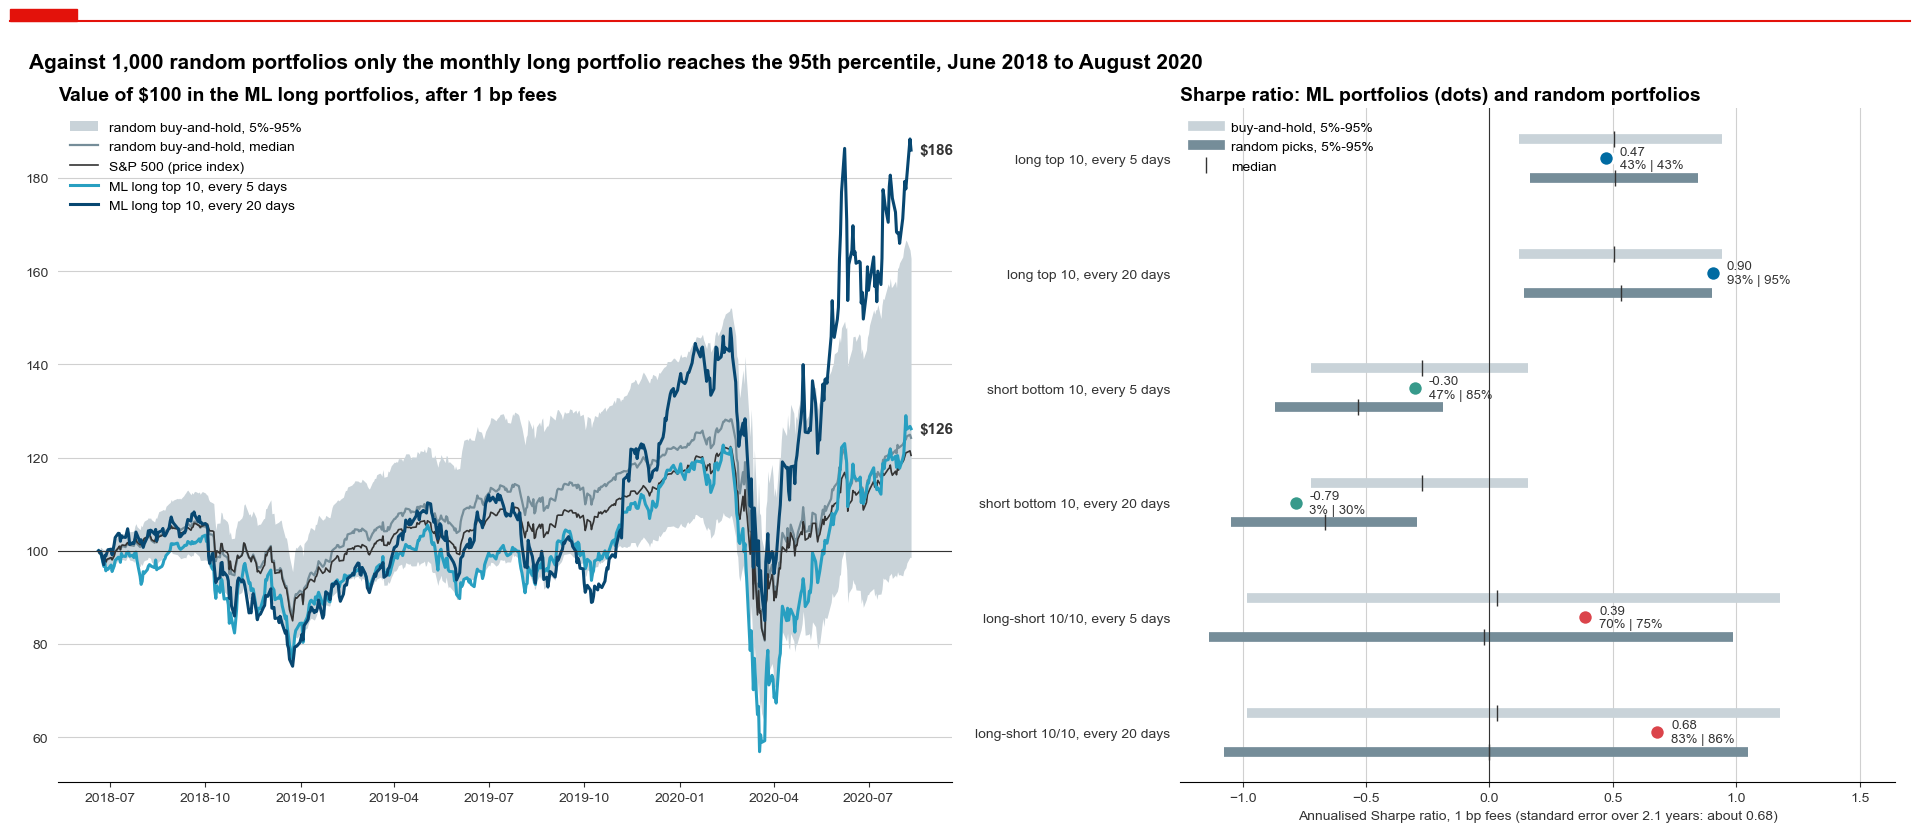

In [242]:
STRATEGY_COLORS = {"long top 10": ECONOMIST_COLORS[0], "short bottom 10": ECONOMIST_COLORS[2],
                   "long-short 10/10": ECONOMIST_COLORS[8]}

fig, (value_ax, sharpe_ax) = plt.subplots(1, 2, figsize=(19, 8), gridspec_kw={"width_ratios": [1.25, 1]})

# left: $100 in the ML long portfolios, the random buy-and-hold portfolios and the index
value_ax.fill_between(band.index, band[0.05], band[0.95], color=LIGHT_GREY, lw=0, label="random buy-and-hold, 5%-95%")
value_ax.plot(band.index, band[0.5], color=GREY, lw=1.6, label="random buy-and-hold, median")
value_ax.plot(sp500.index, sp500, color=DARK, lw=1.2, label="S&P 500 (price index)")
for h in HORIZONS:
    values = strategies[h]["long top 10"]["values"][FEE]
    value_ax.plot(values.index, values, color=HORIZON_COLORS[h], lw=2.2, label=f"ML long top 10, every {h} days")
    annotate(value_ax, f"${values.iloc[-1]:.0f}", (values.index[-1], values.iloc[-1]), offset=(6, 0), fontsize=11,
             fontweight="bold")
value_ax.axhline(100, color=DARK, lw=0.8)
value_ax.set_title("Value of $100 in the ML long portfolios, after 1 bp fees")
value_ax.legend(loc="upper left", fontsize=10)
value_ax.grid(False, axis="x")

# right: every ML Sharpe ratio (dot) on the 5%-95% range of the two random benchmarks (bars)
rows = [(name, h) for name in STRATEGY_COLORS for h in HORIZONS]
for i, (name, h) in enumerate(rows):
    strategy = strategies[h][name]
    for shift, benchmark, color in [(-0.17, "buy and hold", LIGHT_GREY), (0.17, "random picks", GREY)]:
        low, middle, high = sharpe_ratio(strategy[benchmark]).quantile([0.05, 0.5, 0.95])
        sharpe_ax.plot([low, high], [i + shift] * 2, color=color, lw=7, solid_capstyle="butt")
        sharpe_ax.plot(middle, i + shift, marker="|", color=DARK, ms=11)
    sharpe, beats_hold, beats_picks = task4.loc[(f"every {h} days", name), [
        "Sharpe (1 bp)", "Sharpe beats random buy-and-hold", "Sharpe beats random picks"]]
    sharpe_ax.scatter(sharpe, i, s=120, color=STRATEGY_COLORS[name], edgecolors="white", linewidths=2, zorder=3)
    annotate(sharpe_ax, f"{sharpe:.2f}\n{beats_hold:.0%} | {beats_picks:.0%}", (sharpe, i), offset=(10, 0))
sharpe_ax.set_yticks(range(len(rows)), [f"{name}, every {h} days" for name, h in rows])
sharpe_ax.invert_yaxis()
sharpe_ax.axvline(0, color=DARK, lw=0.8)
vertical_grid(sharpe_ax)
sharpe_ax.set_xlabel(f"Annualised Sharpe ratio, 1 bp fees (standard error over {test_years:.1f} years: "
                     f"about {1 / np.sqrt(test_years):.2f})")
sharpe_ax.set_title("Sharpe ratio: ML portfolios (dots) and random portfolios")
sharpe_ax.set_xlim(right=sharpe_ax.get_xlim()[1] + 0.35)                               # room for the labels
sharpe_ax.legend(handles=[plt.Line2D([], [], color=LIGHT_GREY, lw=7, label="buy-and-hold, 5%-95%"),
                          plt.Line2D([], [], color=GREY, lw=7, label="random picks, 5%-95%"),
                          plt.Line2D([], [], color=DARK, marker="|", ls="", ms=11, label="median")],
                 loc="upper left", fontsize=10)

show("Against 1,000 random portfolios only the monthly long portfolio reaches the 95th percentile, "
     "June 2018 to August 2020")

In [243]:
# The value of $100 at the end of the test period: the ML portfolios by fee level and the two buy-and-hold benchmarks
final_values = task4[["$100 becomes", "after 1 bp", "after 10 bp"]].astype(float).set_axis(
    ["no fees", "1 bp", "10 bp"], axis=1)
benchmarks = pd.DataFrame({"no fees": [equal_weights.iloc[-1], sp500.iloc[-1]]},
                          index=pd.MultiIndex.from_tuples([("benchmark", f"1/N on all {universe.shape[1]} stocks"),
                                                           ("benchmark", "S&P 500 (price index)")]))
pd.concat([final_values, benchmarks]).style.format("{:.2f}", na_rep="").set_caption("Value of 100 dollars at the end of the test period")

In [244]:
# NN3's ranking: the average realised 20-day return (%) of its ten forecast groups, from 1 (lowest) to 10 (highest)
decile_returns = pd.DataFrame({"all test days": by_decile.mean(),
                               "before COVID": by_decile.loc[before_covid].mean()}).T
decile_returns.style.format("{:.2f}%").set_caption("Average 20-day return of NN3's ten forecast groups, lowest to highest")

,1,2,3,4,5,6,7,8,9,10
all test days,1.16%,1.13%,1.15%,1.00%,0.99%,0.98%,1.02%,1.15%,1.26%,1.56%
before COVID,1.11%,1.15%,1.23%,1.16%,1.13%,1.19%,1.19%,1.30%,1.22%,1.38%


In [245]:
# 3) Survivorship check: the strategies among the larger half of the stocks by 20-day dollar volume, known each day
large_half = (close * volume).rolling(20).mean().rank(axis=1, pct=True) > 0.5
larger = pd.DataFrame({(f"every {h} days", name): summary_row(strategy) for h in HORIZONS
                       for name, strategy in sp500_strategies(h, eligible=large_half).items()}).T
survivorship = pd.DataFrame({
    ("Sharpe ratio, 1 bp", "all stocks"): task4["Sharpe (1 bp)"],
    ("Sharpe ratio, 1 bp", "larger half"): larger["Sharpe (1 bp)"],
    ("share of random picks beaten", "all stocks"): task4["Sharpe beats random picks"],
    ("share of random picks beaten", "larger half"): larger["Sharpe beats random picks"],
}).astype(float)
survivorship.style.format({column: "{:.2f}" if column[0].startswith("Sharpe") else "{:.1%}"
                           for column in survivorship.columns})

**Comments – 4.1**

- **\$100 become** \$126.18 and \$185.98 in the long portfolios (rebalanced every 5 and 20 days, after 1 bp fees), \$83.14 and \$64.11 in the short ones and \$117.11 and \$146.12 in the long-short ones, against \$125.92 for 1/N and \$120.47 for the S&P 500. Fees of 1 bp cost at most \$1.67. At 10 bp, Jiang et al.'s cost for large stocks, the weekly long-short portfolio keeps \$103.08.
- **Only the monthly long portfolio (20d) reaches the edge of chance** (right): with a Sharpe ratio of 0.90 it beats 95.1% of the random picks. The other long and long-short portfolios (0.39 to 0.68) beat 43.3% to 86.5% of the random portfolios. One result at the 95th percentile among six strategies is what chance produces. The survivorship check points the same way: among the larger half of the stocks the monthly (20d) long portfolio falls to 0.40 (33.1% of the random picks), while the weekly ones (5d) improve (0.68 and 0.83).
- **NN3's ranking is weak (3.3):** sorted into ten groups by its 20-day forecast, the stocks it liked most earned 1.56% over the next 20 days and those it liked least 1.16%, about as much as groups 2, 3 and 8. The short portfolios lose money, as shorting in a rising market tends to. The monthly one beats only 3.1% of the random buy-and-hold shorts.

### 4.2 Is the ML portfolio more than a beta bet?
High-beta stocks rebound most after a crash, so the ML portfolios may simply buy beta. Two tests:
- **Two one-line rules** with the same rebalancing and fees: **beta**, the 10 highest-beta stocks (the 10 lowest on the short side), and **beta timing**, high-beta stocks after the S&P 500 fell over the past 20 days and low-beta stocks after it rose.
- **Factor regressions** as in Gu et al. (2020, Table 8): daily returns (in excess of the risk-free rate for the long portfolios; the others finance themselves) on the five Fama-French factors, momentum and short-term reversal, with Newey-West standard errors. The alpha is what the seven factors leave unexplained.

In [246]:
FACTORS = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom", "ST_Rev"]
FACTOR_FILES = ["F-F_Research_Data_5_Factors_2x3_daily", "F-F_Momentum_Factor_daily", "F-F_ST_Reversal_Factor_daily"]


def daily_factors(cache="ff_daily_factors_2011-01-01_to_2020-08-11.csv"):
    '''
    Daily Fama-French five factors, momentum and short-term reversal (Ken French's data library),
    in decimals, cached on disk.
    '''
    if not os.path.exists(cache):
        import io, zipfile, requests
        frames = []
        for name in FACTOR_FILES:
            url = f"https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/{name}_CSV.zip"
            reply = requests.get(url, headers={"User-Agent": "Mozilla/5.0 (Bocconi 20598 PC Lab, academic use)"},
                                 timeout=60)
            lines = zipfile.ZipFile(io.BytesIO(reply.content)).read(name + ".csv").decode("latin-1").splitlines()
            start = next(i for i, line in enumerate(lines) if line.startswith(","))      # the header of the daily table
            end = next(i for i in range(start + 1, len(lines)) if not lines[i].strip())
            frames.append(pd.read_csv(io.StringIO("\n".join(lines[start:end])), index_col=0))
        factors = pd.concat(frames, axis=1, join="inner").sort_index()                  # the days all three files cover
        factors.index = pd.to_datetime(factors.index.astype(str), format="%Y%m%d")
        (factors.loc[DOWNLOAD_START:SAMPLE_END] / 100).round(6).to_csv(cache)
    return pd.read_csv(cache, index_col=0, parse_dates=True)


def ols(y, x, hac_lags=0):
    '''
    OLS of y on a constant and x, estimated with statsmodels (as in PC Labs #2 and #3).
    hac_lags > 0 returns Newey-West standard errors.
    '''
    model = sm.OLS(np.asarray(y, dtype=float), sm.add_constant(np.asarray(x, dtype=float)))
    if hac_lags:
        return model.fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    return model.fit()


def factor_regressions(values, long):
    '''
    A portfolio's daily returns on the market (CAPM) and on the seven factors, with Newey-West standard errors:
    the alphas per year with their t-statistics, the seven loadings and the R2.
    '''
    daily = values.pct_change().dropna()
    excess = daily - factors.loc[daily.index, "RF"] if long else daily     # short positions finance themselves
    lags = int(4 * (len(daily) / 100) ** (2 / 9))                          # lag rule of PC Lab #2
    capm, seven = (ols(excess, factors.loc[daily.index, columns], hac_lags=lags) for columns in (["Mkt-RF"], FACTORS))
    return {"CAPM alpha p.a.": capm.params[0] * DAYS, "t(CAPM alpha)": capm.tvalues[0],
            "alpha p.a.": seven.params[0] * DAYS, "t(alpha)": seven.tvalues[0],
            **dict(zip(FACTORS, seven.params[1:])), "R2": seven.rsquared}


def beta_forecast(h, timing=False):
    '''
    A stock's beta used as its forecast on the test days of horizon h;
    with timing, minus beta after the S&P 500 rose over 20 days.
    '''
    test = data[h][2]["test"]
    beta = panel.loc[test, "beta"]
    return beta.where(panel.loc[test, "market 20d"] < 0, -beta) if timing else beta

In [247]:
factors = daily_factors()
bets, regressions, overlap = {}, {}, {}
for h in HORIZONS:
    every = f"every {h} days"
    prices = close_filled.loc[test_forecast(h).index[0][0]:]

    # NN3 against the two beta rules: the same portfolios, built on beta instead of a forecast
    candidates = {"NN3": test_forecast(h), "beta": beta_forecast(h), "beta timing": beta_forecast(h, timing=True)}
    for side, direction in SIDES.items():
        for name, forecast in candidates.items():
            values = simulate(ml_weights(forecast, h, side=direction), prices, FEE)[0]
            bets.setdefault((side, name), {}).update({(every, "$100 becomes"): values.iloc[-1],
                                                      (every, "Sharpe"): sharpe_ratio(values.to_frame())[0]})
        regressions[(every, side)] = factor_regressions(strategies[h][side]["values"][FEE], long=direction == "long")

    # how many of NN3's top 10 are also among the 10 highest betas
    nn3_picks, beta_picks = ml_weights(test_forecast(h), h), ml_weights(beta_forecast(h), h)
    overlap[every] = np.mean([((a > 0) & (b > 0)).sum() for (_, a), (_, b) in zip(nn3_picks, beta_picks)])

bets, regressions = pd.DataFrame(bets).T, pd.DataFrame(regressions).T

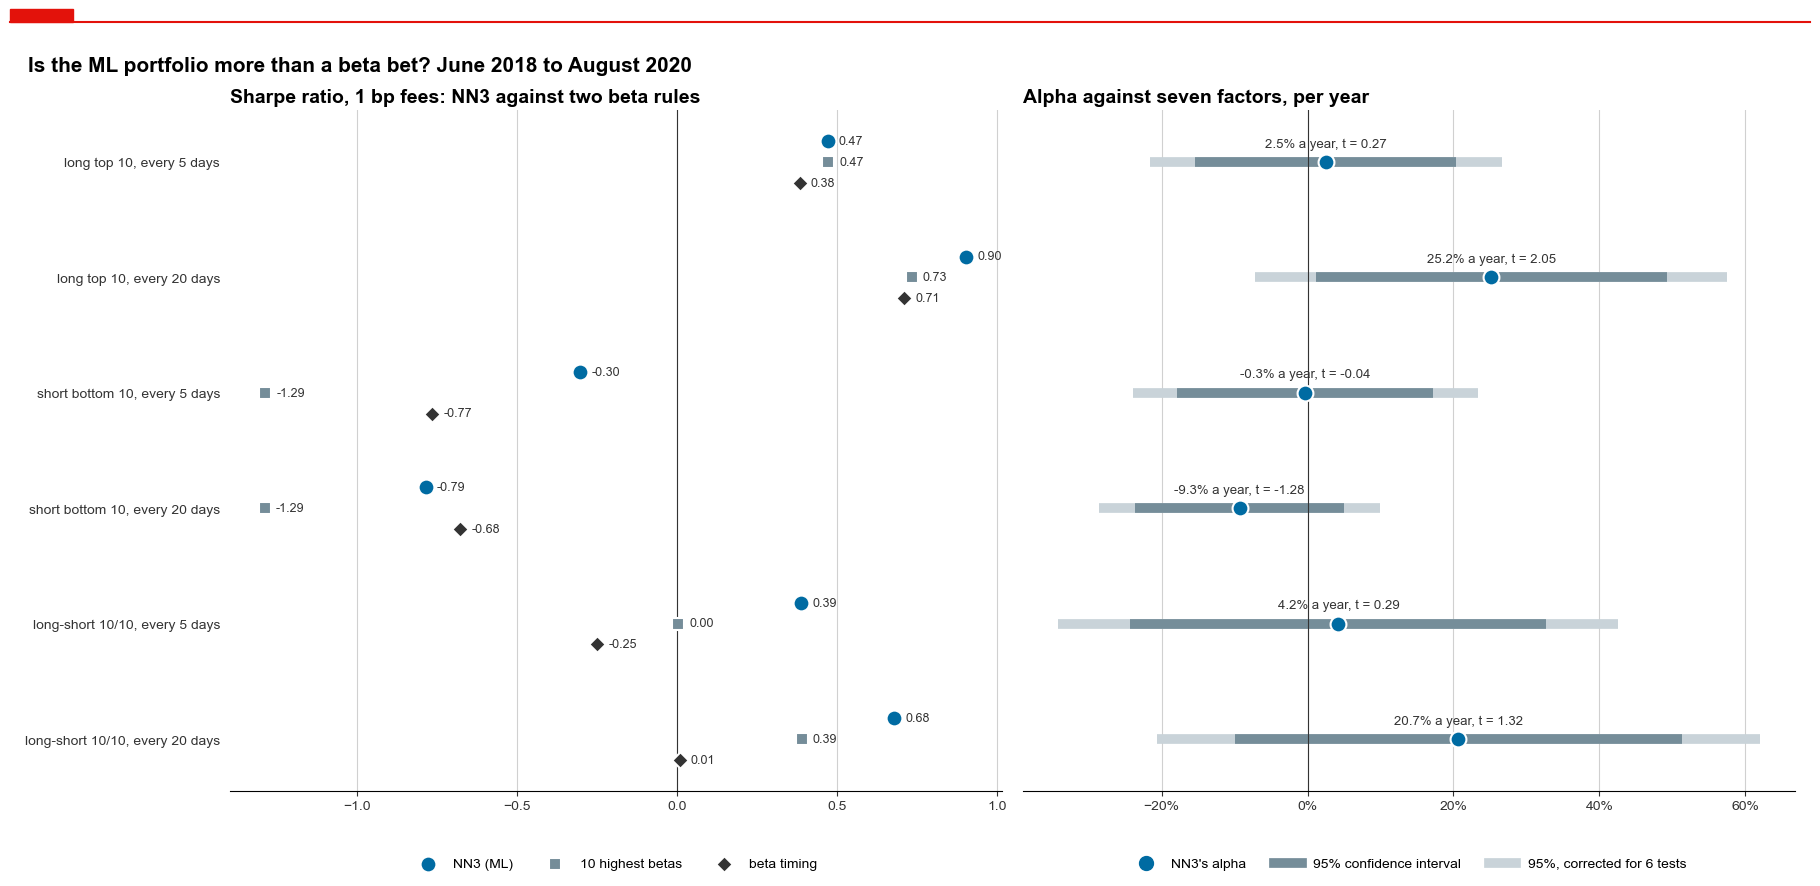

In [248]:
rows = [(side, h) for side in SIDES for h in HORIZONS]
z, z_corrected = norm.ppf(0.975), norm.ppf(1 - 0.025 / len(rows))   # 95%, and corrected for six tests (Bonferroni)
RULES = [("NN3", "NN3 (ML)", "o", ECONOMIST_COLORS[0], 130, -0.18),          # name, legend, marker, colour, size, shift
         ("beta", "10 highest betas", "s", GREY, 80, 0.0),
         ("beta timing", "beta timing", "D", DARK, 70, 0.18)]

fig, (sharpe_ax, alpha_ax) = plt.subplots(1, 2, figsize=(18, 8.5))
alpha_ax.sharey(sharpe_ax)

# left: the Sharpe ratios of NN3 and of the two beta rules
for name, legend, marker, color, size, shift in RULES:
    sharpes = [bets.loc[(side, name), (f"every {h} days", "Sharpe")] for side, h in rows]
    heights = np.arange(len(rows)) + shift
    sharpe_ax.scatter(sharpes, heights, marker=marker, s=size, color=color, edgecolors="white", linewidths=1.5,
                      zorder=3, label=legend)
    for sharpe, height in zip(sharpes, heights):
        annotate(sharpe_ax, f"{sharpe:.2f}", (sharpe, height), offset=(8, 0), fontsize=9)
sharpe_ax.set_yticks(range(len(rows)), [f"{side}, every {h} days" for side, h in rows])
sharpe_ax.invert_yaxis()
sharpe_ax.set_title("Sharpe ratio, 1 bp fees: NN3 against two beta rules")
sharpe_ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=10)

# right: NN3's seven-factor alphas with their confidence intervals
for i, (side, h) in enumerate(rows):
    alpha, t = regressions.loc[(f"every {h} days", side), ["alpha p.a.", "t(alpha)"]]
    for width, color in [(z_corrected, LIGHT_GREY), (z, GREY)]:
        alpha_ax.plot([alpha - width * alpha / t, alpha + width * alpha / t], [i, i], color=color, lw=7,
                      solid_capstyle="butt")
    alpha_ax.scatter(alpha, i, s=130, color=ECONOMIST_COLORS[0], edgecolors="white", linewidths=1.5, zorder=3)
    annotate(alpha_ax, f"{alpha:.1%} a year, t = {t:.2f}", (alpha, i), offset=(0, 11), va="baseline")
alpha_ax.set_title("Alpha against seven factors, per year")
alpha_ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
alpha_ax.legend(handles=[plt.Line2D([], [], color=ECONOMIST_COLORS[0], marker="o", ls="", ms=10, label="NN3's alpha"),
                         plt.Line2D([], [], color=GREY, lw=7, label="95% confidence interval"),
                         plt.Line2D([], [], color=LIGHT_GREY, lw=7, label=f"95%, corrected for {len(rows)} tests")],
                loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=10)
alpha_ax.tick_params(axis="y", labelleft=False)

for ax in (sharpe_ax, alpha_ax):
    ax.axvline(0, color=DARK, lw=0.8)
    vertical_grid(ax)
show("Is the ML portfolio more than a beta bet? June 2018 to August 2020")

In [249]:
print("NN3's top 10 that are also among the 10 highest betas, on average:",
      {every: round(float(n), 1) for every, n in overlap.items()})
monthly = regressions.xs("every 20 days", level=0).astype(float)
print("Monthly portfolios against the seven factors: " + " | ".join(
    f"{side} R2 {row['R2']:.2f} ("
    + ", ".join(f"{factor} {row[factor]:+.2f}" for factor in FACTORS if abs(row[factor]) >= 0.4) + ")"
    for side, row in monthly.iterrows()))

NN3's top 10 that are also among the 10 highest betas, on average: {'every 5 days': 1.4, 'every 20 days': 1.2}
Monthly portfolios against the seven factors: long top 10 R2 0.83 (Mkt-RF +1.20, SMB +0.42, Mom -0.62) | short bottom 10 R2 0.70 (Mkt-RF -0.80, CMA -0.92) | long-short 10/10 R2 0.58 (SMB +0.56, CMA -1.05, Mom -1.06)


**Comments – 4.2**

- **NN3 beats both beta rules in four of the six portfolios** (left): every month its long portfolio reaches a Sharpe ratio of 0.90 against 0.73 for the 10 highest betas and 0.71 for beta timing, and its long-short portfolio 0.68 against 0.39 and 0.01. Every week its short (−0.30 against −1.29 and −0.77) and long-short portfolios (0.39 against 0.00 and −0.25) do better too. Its top 10 hold only 1.4 and 1.2 of the 10 highest betas on average.
- **No significant positive alpha against seven factors** (right): the monthly long portfolio earns 25.2% a year more than its factor exposures explain ($t$ = 2.05), significant on its own but not after correcting for six tests (critical value 2.6). The other alphas lie between −9.3% and 20.7% a year ($t$ = −1.28 to 1.32). Gu et al.'s network portfolios keep large, significant alphas (their Table 8). Ours do not.
- **Mostly known factor bets:** the seven factors explain 83%, 70% and 58% of the daily variance of the monthly long, short and long-short portfolios. The long one loads 1.20 on the market.

## Conclusion
The figure shows every model as one dot:
- **Left to right: ranking skill**, the rank IC on the test days. Further right is better.
- **Bottom to top: money made**, the Sharpe ratio of the model's long-short portfolio from Task #4 (10 best minus 10 worst forecasts, rebalanced every $h$ days, 1 bp fees). Higher is better.

Two lines help to judge the dots. The vertical line marks a random ranking. The dashed line marks the 95th percentile of the 1,000 random long-short portfolios of 4.1: a dot above it beats 95% of random portfolios.

In [250]:
FINAL_MODELS = ["OLS (4 signals)", "Ridge (4 signals)", "Ridge (12 signals)", "Elastic net", "Bayesian ridge",
                "Random forest", "XGBoost", "NN3"]

summary = {}                                    # every model's rank IC and the Sharpe ratio of its long-short portfolio
for h, (X, y, masks) in data.items():
    test = masks["test"]
    prices = close_filled.loc[test_forecast(h).index[0][0]:]
    for model in FINAL_MODELS:
        long_short = simulate(ml_weights(test_forecast(h, model), h, side="long-short"), prices, FEE)
        summary[(h, model)] = {"rank IC": rank_ic(y[test], forecasts[h][model], dates[test])[0],
                               "long-short Sharpe": sharpe_ratio(long_short)[0]}
summary = pd.DataFrame(summary).T

# the line of luck: the 95th percentile of 4.1's random long-short picks
random_95 = {h: sharpe_ratio(strategies[h]["long-short 10/10"]["random picks"]).quantile(0.95) for h in HORIZONS}

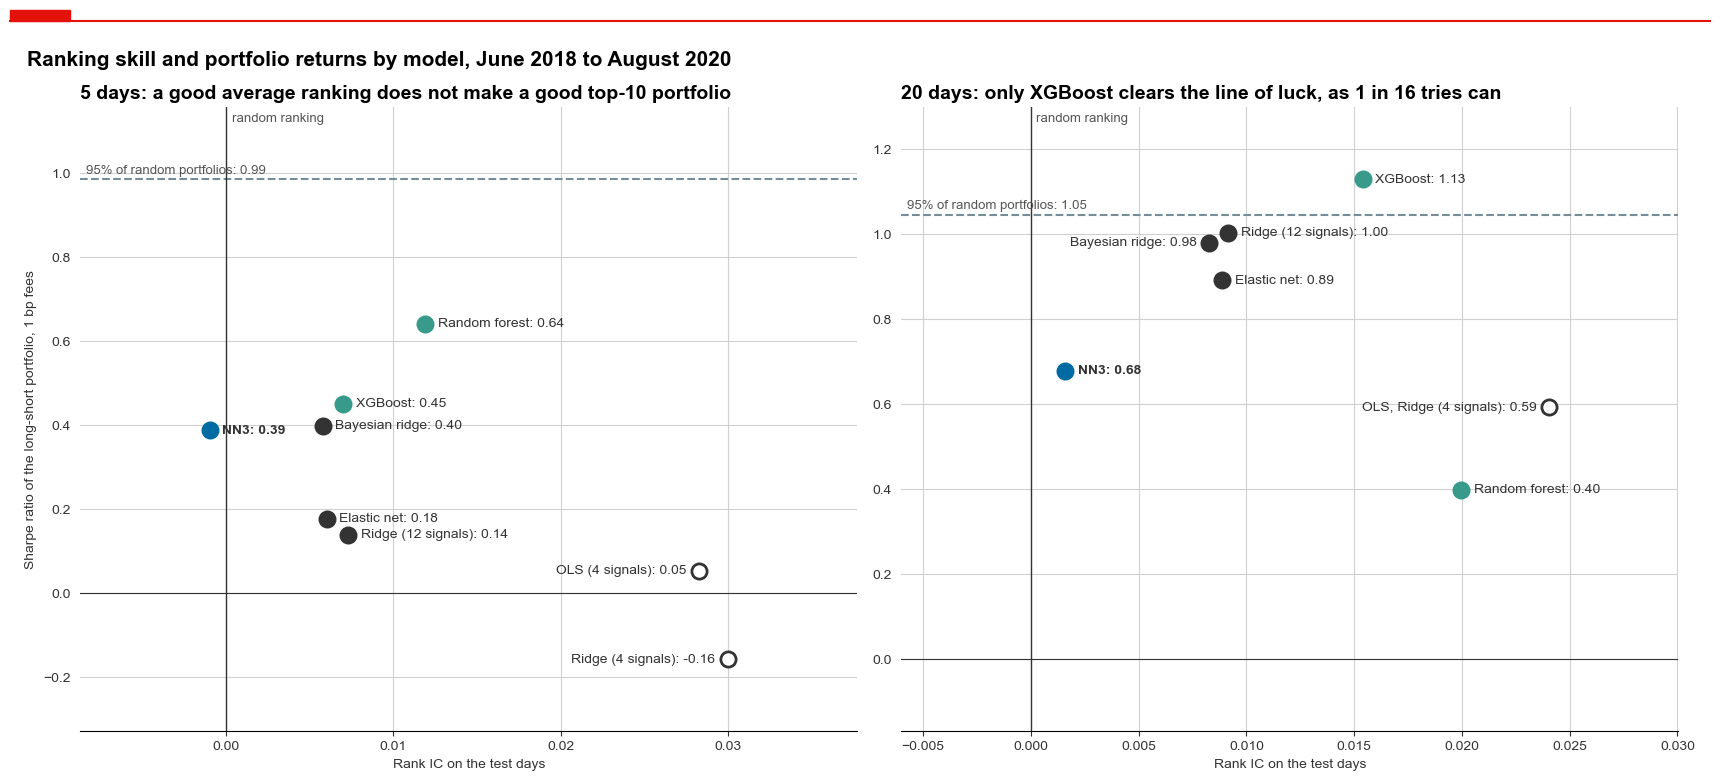

In [251]:
# (horizon, first model of a dot): the labels that go left of their dot, where they would overlap on the right
LABELS_ON_THE_LEFT = {(5, "OLS (4 signals)"), (5, "Ridge (4 signals)"), (20, "OLS (4 signals)"), (20, "Bayesian ridge")}


def dot_label(names):
    '''One label for models whose forecasts coincide, such as OLS and Ridge on the four base signals.'''
    if len(names) > 1 and all(name.endswith("(4 signals)") for name in names):
        return ", ".join(name.replace(" (4 signals)", "") for name in names) + " (4 signals)"
    first_line, second_line = ", ".join(names[:2]), ", ".join(names[2:])                  # long lists on two lines
    return first_line + (",\n" + second_line if second_line else "")


fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
titles = {5: "5 days: a good average ranking does not make a good top-10 portfolio",
          20: "20 days: only XGBoost clears the line of luck, as 1 in 16 tries can"}
for ax, h in zip(axes, HORIZONS):
    part = summary.xs(h, level=0).astype(float)
    ax.axhline(random_95[h], color=GREY, lw=1.5, ls="--")
    ax.axvline(0, color=DARK, lw=1)
    ax.axhline(0, color=DARK, lw=0.8)

    # models with the same forecasts share one dot
    key = pd.Series(list(zip(part["rank IC"].round(3), part["long-short Sharpe"].round(1))), index=part.index)
    for position, names in key.groupby(key).groups.items():
        names = [name for name in FINAL_MODELS if name in names]
        sharpes = part.loc[names, "long-short Sharpe"]
        x, sharpe = part.loc[names, "rank IC"].mean(), sharpes.mean()
        color = MODEL_COLORS.get(names[0], DARK)
        hollow = names[0].endswith("(4 signals)")                            # the base signals of Task #2
        ax.scatter(x, sharpe, s=120, facecolors="white" if hollow else color, edgecolors=color, linewidths=2, zorder=3)

        low, high = sharpes.min(), sharpes.max()
        value = f"{low:.2f}" if round(low, 2) == round(high, 2) else f"{low:.2f} to {high:.2f}"
        annotate(ax, f"{dot_label(names)}: {value}", (x, sharpe), fontsize=10,
                 offset=(-9, 0) if (h, names[0]) in LABELS_ON_THE_LEFT else (9, 0),
                 fontweight="bold" if "NN3" in names else "normal")

    annotate(ax, f"95% of random portfolios: {random_95[h]:.2f}", (0, random_95[h]),
             xycoords=("axes fraction", "data"), offset=(4, 4), va="baseline", color="#555555")
    annotate(ax, "random ranking", (0, 1), xycoords=("data", "axes fraction"), offset=(4, -4), va="top",
             color="#555555")
    ax.set_xlabel("Rank IC on the test days")
    ax.set_title(titles[h])
    ax.margins(x=0.25, y=0.15)
    ax.grid(True, axis="x", color=GRID)
axes[0].set_ylabel("Sharpe ratio of the long-short portfolio, 1 bp fees")
show("Ranking skill and portfolio returns by model, June 2018 to August 2020")

**The questions of the slides, answered.**
1) **Returns and volume changes** (1.2): volume rises with the size of the return, barely with its sign, and does not predict the next day's return.
2) **$R^2_{OOS}$ of OLS and Ridge on the four base signals** (2.4): 0.30% and 0.29% at 5 days, 0.99% for both at 20 days. 88% and 97% of it is the average return.
3) **Is $R^2_{OOS}$ a good metric?** To rank forecasts on the same test days, yes. As evidence of skill, no: its zero benchmark lets the average return pass for skill, and a few volatile weeks and the size of the forecasts dominate it. We therefore benchmark with the rank IC, the ranking of stocks a portfolio needs, and with the Sharpe ratio (figure). The two often disagree: at 5 days the best rankers, OLS and Ridge on the four base signals, build the worst long-short portfolios (0.05 and −0.16), and at 20 days XGBoost's portfolio (1.13) is the only one to clear the 95th percentile of the random portfolios (1.05), one of 16 tries.
4) **The market and more signals** (2 bis, 3.4): the market cannot change a linear model's ranking and barely changes the others'. The extra stock signals help on the validation days and hurt on the test days.
5) **Best machine learning method** (Task #3): by ranking, the forest (rank IC 0.012 and 0.020), though none beats the four base signals of Task #2. NN3, Gu et al.'s best, ranks no better than chance.
6) **\$100 in the ML portfolio** (4.1), after 1 bp fees, rebalanced every 5 and 20 days: \$126.18 and \$185.98 long, \$83.14 and \$64.11 short, \$117.11 and \$146.12 long-short. The fees cost at most \$1.67.
7) **Against 1,000 random portfolios** (4.1): only the monthly long portfolio reaches the edge, beating 95.1% of the random picks. With six strategies, chance produces that about one time in four.

**Our answer to Jim Simons.** Weekly and monthly prices and volumes of large US stocks rank stocks barely better than chance: the best rank IC is about 0.03, from the four base signals of Task #2, and it is unstable from day to day. What $R^2_{OOS}$ counts as skill is mostly the average return (2.4) or, with the market signals, a bet on the market's level (3.3). The ranking also flips from year to year: on average our models rank well in 2019 and worse than chance in 2018 and 2020, and re-estimating them every year does not help (3.5). Our best portfolios, NN3's monthly long and XGBoost's monthly long-short, sit just at the 95% line of luck after many tries, NN3's with a ranking no better than chance, and among the larger stocks NN3's monthly edge disappears (4.1). Gu et al. find that a neural network forecasts best and earns alpha. In our setting it ranks stocks no better than chance and no portfolio earns a significant positive alpha (4.2). Jiang et al. (2023) find price patterns weakest among the largest stocks, where we looked. And a two-year test cannot separate skill from luck: a Sharpe ratio measured over 2.1 years has a standard error of about 0.68. A real test needs decades of data with the historical index members.

**The questions of the slides, answered.**
1. **Do returns and volumes move together?** (1.2) Volume rises when prices move strongly, up or down. It does not predict the next day's return.
2. **How well do OLS and Ridge do?** (2.4) Their $R^2_{OOS}$ is positive, but almost all of it comes from the average return, not from the signals. Ridge barely differs from OLS.
3. **Is $R^2_{OOS}$ a good metric?** For comparing forecasts, yes. As evidence of skill, no: it lets the average return pass for skill. So we judge models by how well they rank stocks (rank IC) and by the Sharpe ratio of their portfolios.
4. **Do ranking skill and money go together?** Often not. At 5 days, the best rankers build the worst portfolios. At 20 days, only XGBoost beats the line of luck, one of 16 tries.
5. **Do the market and more signals help?** (2 bis, 3.4) The market cannot change a linear model's ranking and barely changes the others. The extra stock signals help on the validation days but hurt on the test days.
6. **Which machine learning method is best?** (Task #3) The random forest ranks best, but no model beats the four simple signals of Task #2. NN3, the best model in Gu et al., ranks no better than chance.
7. **What do \$100 become?** (4.1) The long portfolios grow to \$126 (weekly) and \$186 (monthly); the short ones lose money. Fees of 1 bp barely matter, but also do not reflect realistic fees, that market participants are confronted with.
8. **Do we beat random portfolios?** (4.1) Only the monthly long portfolio reaches the edge of chance. With six strategies, chance alone does that about one time in four.

**Our answer to Jim Simons: no, not well enough to trade on.** Prices and volumes rank large US stocks barely better than chance, and the ranking is unstable from day to day. $R^2_{OOS}$ hides this, because what it counts as skill is mostly the average return, or a bet on the market's level. The ranking also changes from year to year: our models rank well in 2019 but worse than chance in 2018 and 2020, and re-estimating them every year does not help (3.5). As a result, our best portfolios sit at the edge of luck. They reach the 95% line only after many tries, and among the larger stocks the best one loses its edge (4.1).

This differs from Gu et al., whose neural network forecasts best and earns alpha. In our data it does neither (4.2). It is, however, in line with Jiang et al. (2023), who find price patterns weakest among the largest stocks, which is where we looked. Finally, two years of data cannot separate skill from luck and a real test needs decades of data with the historical index members.